# `py-nichede` tutorial — niche-differential expression on a 10x Visium liver metastasis

**Notebook 2 of 4.** Audience: a Python user new to Niche-DE. No R appears in any executed
cell; each subsection shows the R one-liner in markdown only, for readers arriving from
`nicheDE`.

## 1. What this package does

**Niche-DE** (Mason K. *et al.*, *"Niche-DE: niche-differential gene expression analysis in
spatial transcriptomics data identifies context-dependent cell–cell interactions"*,
[*Genome Biology* **25**:14 (2024)](https://pmc.ncbi.nlm.nih.gov/articles/PMC10785550/))
answers the question one step beyond spatially-variable genes:

> **Does cell type A express different genes when it sits next to cell type B?**

For every gene it regresses the spot-level counts on the interaction between (a) the posterior
share of that gene's expression attributable to each *index* cell type and (b) a
kernel-smoothed **effective niche** describing which cell types surround the spot, and reports
a Wald statistic per `(index, niche, gene)` triple. Those are then pooled into three nested
resolutions of p-value: interaction, cell type and gene level.

**Input** — four aligned matrices (or an `AnnData` plus two of them):

| matrix | shape | what it is |
|---|---|---|
| `counts_mat` | spots × genes | raw spatial counts |
| `coordinate_mat` | spots × 2 | spot coordinates |
| `library_mat` | cell types × genes | average expression profile per cell type (from a reference scRNA-seq atlas) |
| `deconv_mat` | spots × cell types | deconvolution weights (RCTD, cell2location, …) |

**Output** — a `NicheDEObject` carrying, per kernel bandwidth, a per-gene `T_stat` /
`betas` / `Varcov`, plus BH-adjusted p-values at gene, cell-type and interaction level, plus
downstream tables: niche-DE gene lists, niche marker genes, and ligand–receptor calls.

`pynichede` is a pure-Python port of the R package
[`kaishumason/NicheDE`](https://github.com/kaishumason/NicheDE) (MIT).
Numerical parity with R is validated in
[`compare_R_vs_Python.ipynb`](compare_R_vs_Python.ipynb).

## 2. Install + import

```bash
pip install py-nichede
```

Runtime dependencies are only `numpy, scipy, pandas, anndata, joblib` — no R, no `rpy2`,
no GPL code (see `DISCOVERY.md` §3–4 for the dependency audit).

In [1]:
%matplotlib inline
import os, sys, json, re, time, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PKG_ROOT = os.environ.get("PYNICHEDE_ROOT",
                          "/scratch/users/steorra/analysis/omicverse_dev/py-nichede")
REF_DIR  = os.environ.get("NICHEDE_REF_DIR",     "/scratch/users/steorra/nichede_ref_out/full")
DEV_DIR  = os.environ.get("NICHEDE_DEV_REF_DIR", "/scratch/users/steorra/nichede_ref_out/dev300")
PERFUNC  = os.environ.get("NICHEDE_PERFUNC_DIR", "/scratch/users/steorra/nichede_ref_out/perfunc")
RSCRIPT  = os.environ.get("NICHEDE_RSCRIPT",     "/scratch/users/steorra/env/CMAP/bin/Rscript")
R_LIBS   = os.environ.get("NICHEDE_R_LIBS",      "/scratch/users/steorra/Rlibs_nichede")
N_JOBS   = int(os.environ.get("NICHEDE_N_JOBS", "16"))

os.environ.setdefault("TMPDIR", "/scratch/users/steorra/tmp")
os.environ.setdefault("JOBLIB_TEMP_FOLDER", os.environ["TMPDIR"])
os.makedirs(os.environ["TMPDIR"], exist_ok=True)
for _p in (PKG_ROOT, os.path.join(PKG_ROOT, "tests")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from refload import RefDump                      # tests/refload.py
from parity_report import det, corr, infer       # tests/parity_report.py
import pynichede as nde

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.autolayout": True})
C_R, C_PY, C_BAD = "#1f4e79", "#c1440e", "#8b0000"

def sub(a, n=20000, seed=0):
    """Deterministic subsample of a flat array, for readable scatter plots."""
    a = np.asarray(a).ravel()
    if a.size <= n:
        return np.arange(a.size)
    return np.sort(np.random.default_rng(seed).choice(a.size, n, replace=False))

def overlay_det(ref, cand, title, unit="", ax=None):
    """`deterministic` visual: sorted R vs Py overlay + the max abs error."""
    r = np.asarray(ref, dtype=float).ravel()
    c = np.asarray(cand, dtype=float).ravel()
    m = np.isfinite(r) & np.isfinite(c)
    o = np.argsort(r[m], kind="stable")
    err = float(np.max(np.abs(r[m] - c[m]))) if m.any() else 0.0
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.1))
    i = sub(r[m][o], 8000)
    ax[0].plot(np.arange(i.size), r[m][o][i], color=C_R, lw=2.2, label="R (nicheDE)")
    ax[0].plot(np.arange(i.size), c[m][o][i], color=C_PY, lw=0.9, ls="--",
               label="Python (pynichede)")
    ax[0].set_xlabel("entry (sorted by the R value)")
    ax[0].set_ylabel(unit or "value")
    ax[0].set_title(f"{title} — overlay")
    ax[0].legend(loc="upper left")
    d = np.abs(r[m] - c[m])
    d = d[d > 0]
    if d.size:
        ax[1].hist(np.log10(d), bins=50, color=C_PY, alpha=0.85)
        ax[1].set_xlabel("log10 |R - Python|")
    else:
        ax[1].text(0.5, 0.5, "bit-identical\n(all differences exactly 0)",
                   ha="center", va="center", transform=ax[1].transAxes)
        ax[1].set_xticks([])
    ax[1].set_ylabel("count")
    ax[1].set_title(f"max |err| = {err:.3e}   (n = {int(m.sum())})")
    return err

def scatter_corr(ref, cand, title, ax=None, label="T_stat"):
    """`pearson` / ordinal visual: R vs Py scatter with Pearson + Spearman."""
    st = corr(ref, cand)
    r = np.asarray(ref, dtype=float).ravel()
    c = np.asarray(cand, dtype=float).ravel()
    m = np.isfinite(r) & np.isfinite(c)
    i = sub(r[m], 25000)
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.0, 3.8))
    ax.scatter(r[m][i], c[m][i], s=3, alpha=0.25, color=C_PY, edgecolors="none")
    lo, hi = float(np.min(r[m])), float(np.max(r[m]))
    ax.plot([lo, hi], [lo, hi], color=C_R, lw=1.0, ls="--", label="y = x")
    ax.set_xlabel(f"R {label}")
    ax.set_ylabel(f"Python {label}")
    ax.set_title(f"{title}\nPearson {st['pearson']:.6f} | Spearman {st['spearman']:.6f}\n"
                 f"n = {st['n']}, max|err| = {st['max_abs_err']:.2e}", fontsize=8)
    ax.legend(loc="upper left", fontsize=7)
    return st

def scatter_pval(ref, cand, title, axes=None, ks=(10, 25, 50, 100, 250, 500)):
    """`inference` visual: -log10(p) scatter + top-K overlap curve."""
    st = infer(ref, cand)
    r = np.clip(np.asarray(ref, dtype=float).ravel(), 1e-300, 1.0)
    c = np.clip(np.asarray(cand, dtype=float).ravel(), 1e-300, 1.0)
    m = np.isfinite(r) & np.isfinite(c)
    r, c = r[m], c[m]
    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.3))
    i = sub(r, 25000)
    axes[0].scatter(-np.log10(r[i]), -np.log10(c[i]), s=3, alpha=0.25,
                    color=C_PY, edgecolors="none")
    hi = float(np.max(-np.log10(r))) if r.size else 1.0
    axes[0].plot([0, hi], [0, hi], color=C_R, lw=1.0, ls="--")
    axes[0].set_xlabel("R  -log10(p)")
    axes[0].set_ylabel("Python  -log10(p)")
    axes[0].set_title(f"{title}\nSpearman(-log10 p) = {st['spearman_neglog10p']:.6f}"
                      f"  (n = {st['n']})", fontsize=8)
    jac, kk = [], []
    for k in ks:
        k = min(k, r.size)
        a = set(np.argsort(r, kind="stable")[:k].tolist())
        b = set(np.argsort(c, kind="stable")[:k].tolist())
        jac.append(len(a & b) / len(a | b))
        kk.append(k)
    axes[1].plot(kk, jac, "o-", color=C_PY)
    axes[1].axhline(0.70, color=C_BAD, ls="--", lw=1, label="gate 0.70")
    axes[1].set_xscale("log")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xlabel("K (most significant genes)")
    axes[1].set_ylabel("top-K Jaccard(R, Python)")
    axes[1].set_title(f"top-50 Jaccard = {st['top50_jaccard']:.3f}", fontsize=8)
    axes[1].legend(fontsize=7)
    return st

print("pynichede", nde.__version__, "| python", sys.version.split()[0],
      "| numpy", np.__version__, "| scipy", __import__("scipy").__version__)
print("REF_DIR    ", REF_DIR)
print("PERFUNC_DIR", PERFUNC)

pynichede 0.1.0 | python 3.10.20 | numpy 2.2.6 | scipy 1.15.3
REF_DIR     /scratch/users/steorra/nichede_ref_out/full
PERFUNC_DIR /scratch/users/steorra/nichede_ref_out/perfunc


In [2]:
from pynichede import (
    NicheDE,                                   # chainable class API
    create_library_matrix, create_library_matrix_from_anndata,
    create_nichede_object, create_nichede_object_from_anndata,
    merge_objects, filter_nde,
    calculate_effective_niche, calculate_effective_niche_large_scale,
    niche_DE, niche_DE_no_parallel,
    get_niche_DE_pval_fisher, get_niche_DE_pval_raw,
    T_to_p, ultosymmetric, gene_level, celltype_level,
    gene_level_fisher, celltype_level_fisher,
    contrast_post, check_colloc, nb_lik,
    get_niche_DE_genes, niche_DE_markers, niche_LR_spot, niche_LR_cell,
    mvnconv, fisher_generalized,
)
print("public API (pynichede.__all__), %d names:" % len(nde.__all__))
for i in range(0, len(nde.__all__), 4):
    print("   " + "  ".join(f"{n:34s}" for n in nde.__all__[i:i + 4]))

public API (pynichede.__all__), 29 names:
   NicheDE                             NicheDEObject                       create_library_matrix               create_library_matrix_from_anndata
   create_nichede_object               create_nichede_object_from_anndata  merge_objects                       filter_nde                        
   calculate_effective_niche           calculate_effective_niche_large_scale  niche_DE                            niche_DE_no_parallel              
   get_niche_DE_pval_fisher            get_niche_DE_pval_raw               T_to_p                              gene_level                        
   celltype_level                      gene_level_fisher                   celltype_level_fisher               contrast_post                     
   check_colloc                        ultosymmetric                       nb_lik                              get_niche_DE_genes                
   niche_DE_markers                    niche_LR_spot                       nich

## 3. Load demo data

The demo dataset is the one shipped inside the upstream R package: a **10x Visium section of a
human liver metastasis**, 848 spots, 7 RCTD-deconvolved cell types. It arrives here through the
binary dump the R reference driver wrote, so the tutorial and the parity notebook operate on
byte-identical matrices.

Expected workflow length: **object → effective niche → niche_DE → downstream**, four steps.

In [3]:
d = RefDump(REF_DIR)
cts    = list(d.meta["cell_types"])
cells  = list(d.meta["cell_names"])
genes  = list(d.meta["gene_names"])
sigma  = np.atleast_1d(np.asarray(d.meta["sigma"], dtype=float))

counts = pd.DataFrame(d["ref_counts"],   index=cells, columns=genes)
coord  = pd.DataFrame(d["in_coord"],     index=cells, columns=["imagerow", "imagecol"])
libmat = pd.DataFrame(d["ref_ref_expr"], index=cts,   columns=genes)
deconv = pd.DataFrame(d["in_deconv"],    index=cells, columns=cts)

print(f"counts  {counts.shape}  (spots x genes)")
print(f"coord   {coord.shape}")
print(f"libmat  {libmat.shape}  (cell types x genes)")
print(f"deconv  {deconv.shape}")
print("cell types:", cts)
print("kernel bandwidths (sigma):", sigma)

counts  (848, 21708)  (spots x genes)
coord   (848, 2)
libmat  (7, 21708)  (cell types x genes)
deconv  (848, 7)
cell types: ['hepatocytes+cholangiocytes', 'T', 'B_plasma', 'tumor_epithelial', 'endothelial', 'myeloid', 'stromal']
kernel bandwidths (sigma): [  1. 100. 250.]


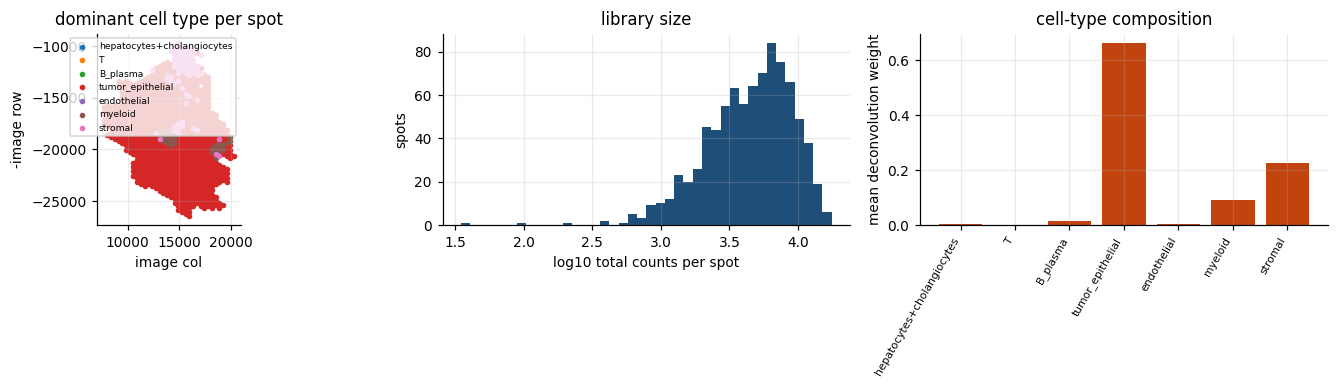

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
nc = np.asarray(deconv, dtype=float)
dom = np.asarray(cts)[nc.argmax(axis=1)]
for ct in cts:
    m = dom == ct
    ax[0].scatter(coord["imagecol"][m], -coord["imagerow"][m], s=7, label=ct)
ax[0].legend(fontsize=6, loc="upper right"); ax[0].set_aspect("equal")
ax[0].set_title("dominant cell type per spot"); ax[0].set_xlabel("image col"); ax[0].set_ylabel("-image row")
ax[1].hist(np.log10(np.asarray(counts).sum(axis=1)), bins=40, color=C_R)
ax[1].set_xlabel("log10 total counts per spot"); ax[1].set_ylabel("spots")
ax[1].set_title("library size")
ax[2].bar(range(len(cts)), nc.mean(axis=0), color=C_PY)
ax[2].set_xticks(range(len(cts))); ax[2].set_xticklabels(cts, rotation=60, ha="right", fontsize=7)
ax[2].set_ylabel("mean deconvolution weight"); ax[2].set_title("cell-type composition")
plt.show()

## 4. One subsection per public function

Every name in `pynichede.__all__` gets its own subsection: what it does, the R one-liner it
mirrors, a call with sensible defaults, the return type and shape, and at least one figure.

### 4.1 `create_library_matrix`

Average expression profile per cell type from a single-cell (or spot-level) counts matrix. This is the `library_mat` the object constructor wants. `cell_type` is a two-column frame whose first column must line up **row for row** with the counts matrix, exactly as R requires. Cell types with more than 1000 cells are downsampled to 1000 — the only RNG anywhere in the package (pass `random_state` to control it).

R equivalent:

```r
L <- nicheDE::CreateLibraryMatrix(data, cell_type)
```

return type : DataFrame
shape       : (4, 21708)  (cell types x genes)
index       : ['ct2', 'ct3', 'ct4', 'ct1']   <- unique(), first-appearance order, like R


,LINC00115,FAM41C,SAMD11,NOC2L,KLHL17,PLEKHN1
ct2,0.028302,0.023585,0.023585,0.485849,0.132075,0.014151
ct3,0.014151,0.042453,0.051887,0.471698,0.155660,0.023585
ct4,0.004717,0.004717,0.037736,0.481132,0.127358,0.023585
ct1,0.033019,0.023585,0.051887,0.419811,0.094340,0.023585


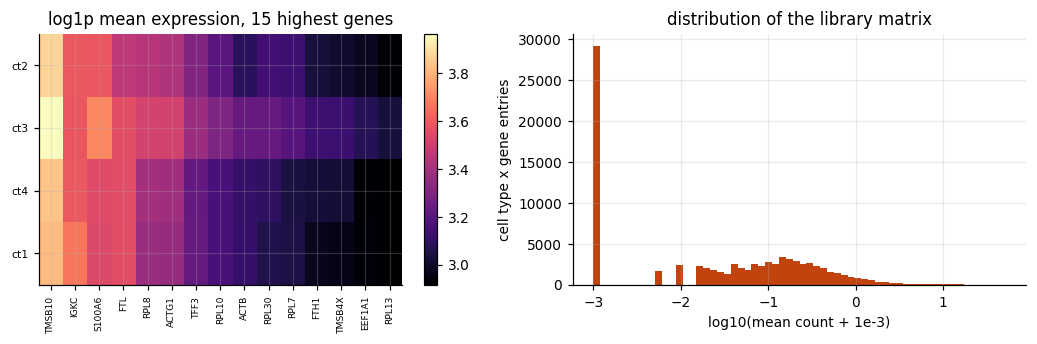

In [5]:
ct_df = pd.DataFrame({"cell": cells, "type": list(d.meta["probe_ct_labels"])})
L_demo = create_library_matrix(counts, ct_df)
print("return type :", type(L_demo).__name__)
print("shape       :", L_demo.shape, " (cell types x genes)")
print("index       :", list(L_demo.index), "  <- unique(), first-appearance order, like R")
display(L_demo.iloc[:, :6])

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
top = np.asarray(L_demo).mean(axis=0).argsort()[::-1][:15]
im = ax[0].imshow(np.log1p(np.asarray(L_demo)[:, top]), aspect="auto", cmap="magma")
ax[0].set_yticks(range(len(L_demo.index))); ax[0].set_yticklabels(L_demo.index, fontsize=7)
ax[0].set_xticks(range(len(top)))
ax[0].set_xticklabels(np.asarray(L_demo.columns)[top], rotation=90, fontsize=6)
ax[0].set_title("log1p mean expression, 15 highest genes"); plt.colorbar(im, ax=ax[0])
ax[1].hist(np.log10(np.asarray(L_demo).ravel() + 1e-3), bins=60, color=C_PY)
ax[1].set_xlabel("log10(mean count + 1e-3)"); ax[1].set_ylabel("cell type x gene entries")
ax[1].set_title("distribution of the library matrix")
plt.show()

### 4.2 `create_library_matrix_from_anndata`

The AnnData flavour of the same thing. `Seurat::Idents(obj)` maps to `adata.obs[celltype_key]`; the assay counts slot maps to `adata.layers[layer]` (or `adata.X`). This is the Python-ecosystem replacement for R's `CreateLibraryMatrixFromSeurat` — the port takes an `AnnData` where R takes a Seurat object, because that is the equivalent object model, not because anything was dropped.

R equivalent:

```r
L <- nicheDE::CreateLibraryMatrixFromSeurat(seurat_object, assay = "RNA")
```

return type : DataFrame  shape: (4, 21708)
identical to the matrix-API result: True  max abs diff = 0.0


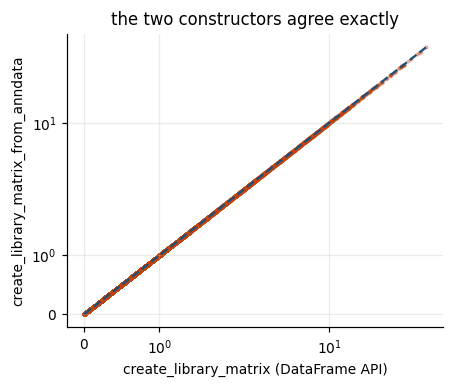

In [6]:
import anndata as ad
sc_demo = ad.AnnData(np.asarray(counts, dtype=np.float64))
sc_demo.obs_names = cells
sc_demo.var_names = genes
sc_demo.obs["cell_type"] = pd.Categorical(list(d.meta["probe_ct_labels"]))
L_ann = create_library_matrix_from_anndata(sc_demo, "cell_type")
print("return type :", type(L_ann).__name__, " shape:", L_ann.shape)
print("identical to the matrix-API result:",
      bool(np.allclose(np.asarray(L_ann), np.asarray(L_demo))),
      " max abs diff =", float(np.max(np.abs(np.asarray(L_ann) - np.asarray(L_demo)))))

fig, ax = plt.subplots(figsize=(4.2, 3.6))
ax.scatter(np.asarray(L_demo).ravel(), np.asarray(L_ann).ravel(), s=3, alpha=0.3, color=C_PY)
ax.plot([0, np.asarray(L_demo).max()], [0, np.asarray(L_demo).max()], ls="--", color=C_R)
ax.set_xscale("symlog"); ax.set_yscale("symlog")
ax.set_xlabel("create_library_matrix (DataFrame API)")
ax.set_ylabel("create_library_matrix_from_anndata")
ax.set_title("the two constructors agree exactly")
plt.show()

### 4.3 `create_nichede_object`

Builds the `NicheDEObject`. It intersects the genes of `counts_mat` and `library_mat` (keeping the **library matrix's** ordering), converts the deconvolution weights into an expected **cell count** per spot, and rescales the coordinates so the mean second-nearest-neighbour spot distance becomes 100 — which is why `sigma` is expressed in those rescaled units and is comparable across datasets. `Int=True` selects the negative-binomial branch, `Int=False` the linear-model branch for continuous (e.g. log-transformed) data.

R equivalent:

```r
obj <- nicheDE::CreateNicheDEObject(counts_mat, coordinate_mat, library_mat,
                                    deconv_mat, sigma = c(1, 100, 250), Int = TRUE)
```

Niche-DE object with 848 observations, 21708 genes, 1 batch(es), and 7 cell types.

slots (named after the R S4 object):
  obj.counts          DataFrame    (848, 21708)
  obj.coord           DataFrame    (848, 2)
  obj.sigma           ndarray      (3,)
  obj.num_cells       DataFrame    (848, 7)
  obj.ref_expr        DataFrame    (7, 21708)
  obj.cell_types      list         7
  obj.gene_names      list         21708
  obj.batch_ID        ndarray      (848,)
  obj.spot_distance   float        
  obj.scale           ndarray      (1,)
  obj.Int             bool         

coordinate rescaling factor: 0.241259437319412 -> spot_distance = 100.0


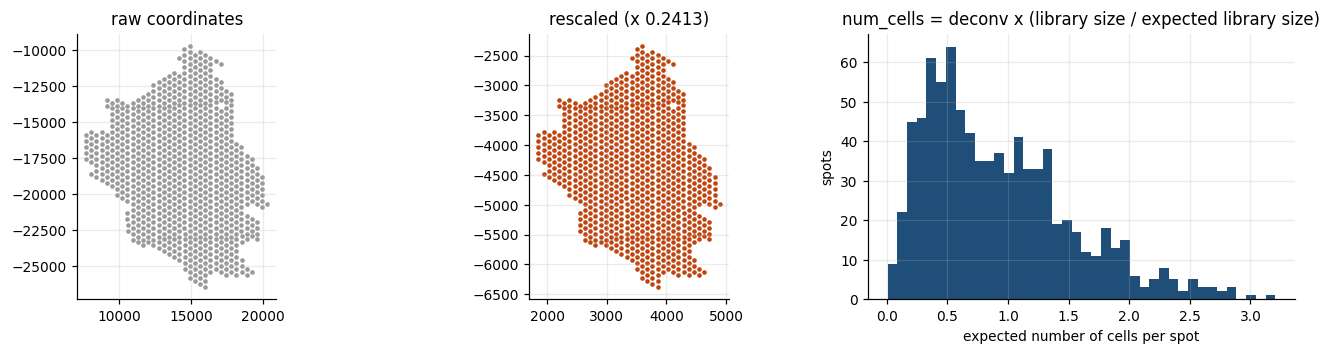

In [7]:
obj = create_nichede_object(counts, coord, libmat, deconv, sigma=sigma, Int=True)
print(obj)                                  # -> mirrors R's print.Niche_DE
print("\nslots (named after the R S4 object):")
for s in ["counts", "coord", "sigma", "num_cells", "ref_expr", "cell_types",
          "gene_names", "batch_ID", "spot_distance", "scale", "Int"]:
    v = getattr(obj, s)
    shape = getattr(v, "shape", None) or (len(v) if hasattr(v, "__len__") else "")
    print(f"  obj.{s:15s} {type(v).__name__:12s} {shape}")
print("\ncoordinate rescaling factor:", float(obj.scale[0]),
      "-> spot_distance =", obj.spot_distance)

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.3))
ax[0].scatter(coord["imagecol"], -coord["imagerow"], s=4, color="#999999", label="raw")
ax[0].set_title("raw coordinates"); ax[0].set_aspect("equal")
ax[1].scatter(obj.coord.iloc[:, 1], -obj.coord.iloc[:, 0], s=4, color=C_PY)
ax[1].set_title(f"rescaled (x {obj.scale[0]:.4f})"); ax[1].set_aspect("equal")
ax[2].hist(np.asarray(obj.num_cells).sum(axis=1), bins=40, color=C_R)
ax[2].set_xlabel("expected number of cells per spot"); ax[2].set_ylabel("spots")
ax[2].set_title("num_cells = deconv x (library size / expected library size)")
plt.show()

### 4.4 `create_nichede_object_from_anndata`

Same constructor, AnnData front end: coordinates come from `adata.obsm[spatial_key]` (R reads `seurat_object@images[[1]]@coordinates$imagerow/imagecol`) and counts from `adata.layers[layer]` or `adata.X`.

R equivalent:

```r
obj <- nicheDE::CreateNicheDEObjectFromSeurat(seurat_object, "Spatial",
                                             library_mat, deconv_mat, sigma)
```

Niche-DE object with 848 observations, 21708 genes, 1 batch(es), and 7 cell types.
num_cells identical to the matrix API: True
coord     identical to the matrix API: True


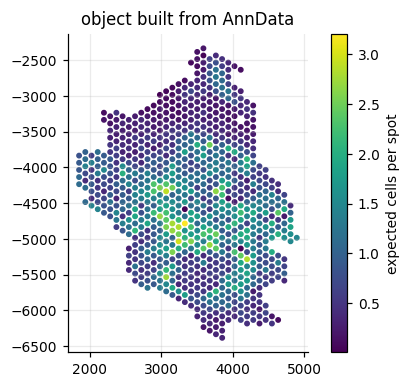

In [8]:
adata = ad.AnnData(np.asarray(counts, dtype=np.float64))
adata.obs_names = cells
adata.var_names = genes
adata.obsm["spatial"] = np.asarray(coord, dtype=np.float64)
obj_ann = create_nichede_object_from_anndata(adata, libmat, deconv, sigma=sigma,
                                             spatial_key="spatial", Int=True)
print(obj_ann)
print("num_cells identical to the matrix API:",
      bool(np.allclose(np.asarray(obj_ann.num_cells), np.asarray(obj.num_cells))))
print("coord     identical to the matrix API:",
      bool(np.allclose(np.asarray(obj_ann.coord), np.asarray(obj.coord))))

fig, ax = plt.subplots(figsize=(4.6, 3.6))
sc_ = ax.scatter(obj_ann.coord.iloc[:, 1], -obj_ann.coord.iloc[:, 0],
                 c=np.asarray(obj_ann.num_cells).sum(axis=1), s=8, cmap="viridis")
plt.colorbar(sc_, ax=ax, label="expected cells per spot")
ax.set_aspect("equal"); ax.set_title("object built from AnnData")
plt.show()
del obj_ann, adata

### 4.5 `calculate_effective_niche`

The heart of the method's spatial part. For each kernel bandwidth `sigma` it computes `EN = K @ num_cells` with `K[i,j] = exp(-d(i,j)^2 / sigma^2)` truncated below `cutoff`, then z-scores each column. A small `sigma` sees only the spot itself; a large one sees the surrounding tissue. Running several bandwidths at once is deliberate — later, each gene is allowed to pick the bandwidth that fits it best via the log-likelihood weights.

R equivalent:

```r
obj <- nicheDE::CalculateEffectiveNiche(obj, cutoff = 0.05)
```

calculate_effective_niche: 0.063 s
return type : NicheDEObject (mutated in place and returned, like R)
obj.effective_niche: list of 3 arrays of shape (848, 7)


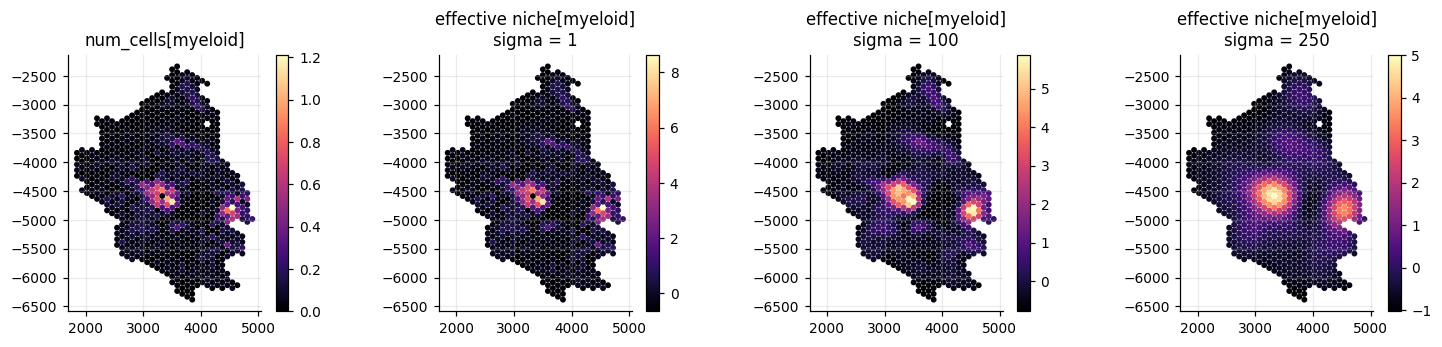

In [9]:
t0 = time.perf_counter()
obj = calculate_effective_niche(obj, cutoff=0.05)
print(f"calculate_effective_niche: {time.perf_counter() - t0:.3f} s")
print("return type :", type(obj).__name__, "(mutated in place and returned, like R)")
print("obj.effective_niche: list of", len(obj.effective_niche), "arrays of shape",
      obj.effective_niche[0].shape)

ct_show = "myeloid"
j = cts.index(ct_show)
fig, ax = plt.subplots(1, len(sigma) + 1, figsize=(3.4 * (len(sigma) + 1), 3.2))
s0 = ax[0].scatter(obj.coord.iloc[:, 1], -obj.coord.iloc[:, 0],
                   c=np.asarray(obj.num_cells)[:, j], s=8, cmap="magma")
ax[0].set_title(f"num_cells[{ct_show}]"); ax[0].set_aspect("equal"); plt.colorbar(s0, ax=ax[0])
for k in range(len(sigma)):
    s_ = ax[k + 1].scatter(obj.coord.iloc[:, 1], -obj.coord.iloc[:, 0],
                           c=obj.effective_niche[k][:, j], s=8, cmap="magma")
    ax[k + 1].set_title(f"effective niche[{ct_show}]\nsigma = {sigma[k]:g}")
    ax[k + 1].set_aspect("equal"); plt.colorbar(s_, ax=ax[k + 1])
plt.show()

### 4.6 `calculate_effective_niche_large_scale`

Same quantity, tiled. Instead of one dense `n_spot x n_spot` distance matrix it splits the tissue into a `ceil(sqrt(n_batches))` grid and, per tile, only considers neighbours inside a bounding box padded by `sigma * sqrt(-log(cutoff))` — the radius past which the Gaussian kernel is guaranteed to be below `cutoff`. That makes the truncation **exact**, not approximate, so the answer equals `calculate_effective_niche` to f64 rounding while the memory stays bounded. Use it when the section has more than ~20 000 spots.

R equivalent:

```r
obj <- nicheDE::CalculateEffectiveNicheLargeScale(obj, batch_size = 1000,
                                                  cutoff = 0.05, standardize = TRUE)
```

large-scale variant: 0.008 s
max abs difference vs the exact routine, per sigma: ['0.00e+00', '1.78e-15', '3.55e-15']


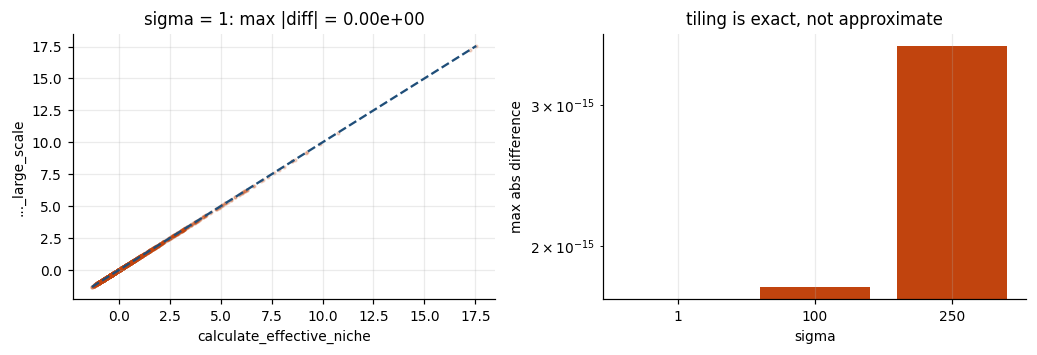

In [10]:
obj_ls = create_nichede_object(counts, coord, libmat, deconv, sigma=sigma, Int=True)
t0 = time.perf_counter()
obj_ls = calculate_effective_niche_large_scale(obj_ls, batch_size=200, cutoff=0.05,
                                               standardize=True)
t_ls = time.perf_counter() - t0
errs = [float(np.max(np.abs(obj.effective_niche[k] - obj_ls.effective_niche[k])))
        for k in range(len(sigma))]
print(f"large-scale variant: {t_ls:.3f} s")
print("max abs difference vs the exact routine, per sigma:", ["%.2e" % e for e in errs])

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.3))
ax[0].scatter(obj.effective_niche[0].ravel(), obj_ls.effective_niche[0].ravel(),
              s=3, alpha=0.2, color=C_PY)
lo, hi = obj.effective_niche[0].min(), obj.effective_niche[0].max()
ax[0].plot([lo, hi], [lo, hi], ls="--", color=C_R)
ax[0].set_xlabel("calculate_effective_niche"); ax[0].set_ylabel("..._large_scale")
ax[0].set_title(f"sigma = {sigma[0]:g}: max |diff| = {errs[0]:.2e}")
ax[1].bar(range(len(sigma)), errs, color=C_PY)
ax[1].set_yscale("log"); ax[1].set_xticks(range(len(sigma)))
ax[1].set_xticklabels([f"{s:g}" for s in sigma]); ax[1].set_xlabel("sigma")
ax[1].set_ylabel("max abs difference"); ax[1].set_title("tiling is exact, not approximate")
plt.show()
del obj_ls

### 4.7 `merge_objects`

Concatenates several `NicheDEObject`s (e.g. several sections of the same study) into one, renormalising each subsequent object's coordinates so that a given `sigma` means the same *physical* distance in every batch, and assigning a `batch_ID`. `niche_DE(..., batch=True)` then puts batch dummies in the design. All objects must share the same kernel bandwidths, the same reference expression matrix, the same cell types and the same gene order.

R equivalent:

```r
obj <- nicheDE::MergeObjects(list(obj1, obj2))
```

Niche-DE object with 1696 observations, 21708 genes, 2 batch(es), and 7 cell types.
return type: NicheDEObject
batch_ID unique values: [1 2]  counts: [848 848]
per-batch scale factors: [1. 2.]


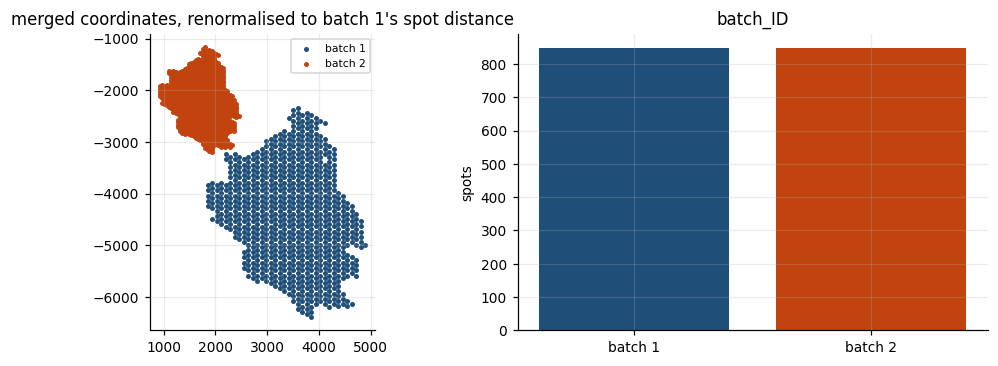

In [11]:
o1 = create_nichede_object(counts, coord, libmat, deconv, sigma=sigma, Int=True)
o2 = create_nichede_object(counts, coord * 2, libmat, deconv, sigma=sigma, Int=True)
om = merge_objects([o1, o2])
print(om)
print("return type:", type(om).__name__)
print("batch_ID unique values:", np.unique(om.batch_ID), " counts:",
      np.bincount(np.asarray(om.batch_ID))[1:])
print("per-batch scale factors:", om.scale)

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.4))
for b, colr in zip(np.unique(om.batch_ID), [C_R, C_PY]):
    m = np.asarray(om.batch_ID) == b
    ax[0].scatter(np.asarray(om.coord)[m, 1], -np.asarray(om.coord)[m, 0],
                  s=5, color=colr, label=f"batch {b}")
ax[0].legend(fontsize=7); ax[0].set_aspect("equal")
ax[0].set_title("merged coordinates, renormalised to batch 1's spot distance")
ax[1].bar(["batch 1", "batch 2"], np.bincount(np.asarray(om.batch_ID))[1:], color=[C_R, C_PY])
ax[1].set_ylabel("spots"); ax[1].set_title("batch_ID")
plt.show()
del o1, o2, om

### 4.8 `filter_nde`

Subsets an object to a set of observations by name — for dropping low-quality spots or restricting to a region of interest. Like R this is a **membership** test, so the surviving rows keep their original order, not the order of `cell_names`. The effective niche is subset too; note it is *not* recomputed, so call it before `calculate_effective_niche` if you want the kernel to ignore the removed spots entirely.

R equivalent:

```r
obj <- nicheDE::Filter_NDE(obj, cell_names)
```

Niche-DE object with 283 observations, 21708 genes, 1 batch(es), and 7 cell types.
kept 283 of 848 spots
order preserved (not reordered to `cell_names`): [np.str_('AAACGAGACGGTTGAT-1'), np.str_('AAAGTGTGATTTATCT-1'), np.str_('AAATAGCTTAGACTTT-1')] ...


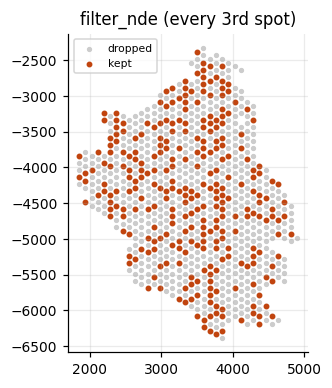

In [12]:
keep = list(np.asarray(obj.cell_names)[::3])
of = filter_nde(obj, keep)
print(of)
print(f"kept {len(of.cell_names)} of {len(obj.cell_names)} spots")
print("order preserved (not reordered to `cell_names`):",
      list(of.cell_names)[:3], "...")

fig, ax = plt.subplots(figsize=(4.6, 3.6))
ax.scatter(obj.coord.iloc[:, 1], -obj.coord.iloc[:, 0], s=6, color="#cccccc", label="dropped")
ax.scatter(of.coord.iloc[:, 1], -of.coord.iloc[:, 0], s=8, color=C_PY, label="kept")
ax.legend(fontsize=7); ax.set_aspect("equal"); ax.set_title("filter_nde (every 3rd spot)")
plt.show()
del of

### 4.9 `niche_DE`

The main event. For each gene and each kernel bandwidth it fits `counts ~ X + batch + offset(log(EEJ))` as a Poisson GLM, where `EEJ` is the expected expression under the null and `X` has one column per ordered *(niche, index)* cell-type pair; then estimates an over-dispersion by Brent minimisation of the negative-binomial negative log-likelihood, and forms Wald statistics from `(X'WX)^-1`. It finally calls `get_niche_DE_pval_fisher` twice to fill in both the positive and the negative p-value tables. `num_cores` maps to joblib workers; `outfile` and `G` exist for signature compatibility and are no-ops.

R equivalent:

```r
obj <- nicheDE::niche_DE(obj, num_cores = 16, outfile = '', C = 150, M = 10,
                         gamma = 0.8, print = TRUE, Int = TRUE, batch = TRUE,
                         self_EN = FALSE, G = 1)
```

/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))


/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))


/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))


/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))


/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))


/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: divide by zero encountered in log
  + x * np.log(mu / (size + mu)))
/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:403: RuntimeWarning: invalid value encountered in multiply
  + x * np.log(mu / (size + mu)))


niche_DE: 32.4 s on 16 workers (21708 genes x 3 kernels)

obj.niche_DE is a list (one per sigma) of one dict per gene:
   T_stat           ndarray    (7, 7)
   betas            ndarray    (7, 7)
   Varcov           ndarray    (16, 16)
   nulls            ndarray    (33,)
   valid            int        
   log_likelihood   float      


/scratch/users/steorra/tmp/ipykernel_28809/3789507615.py:29: RuntimeWarning: Mean of empty slice
  M = np.nanmean(np.abs(T1), axis=2)


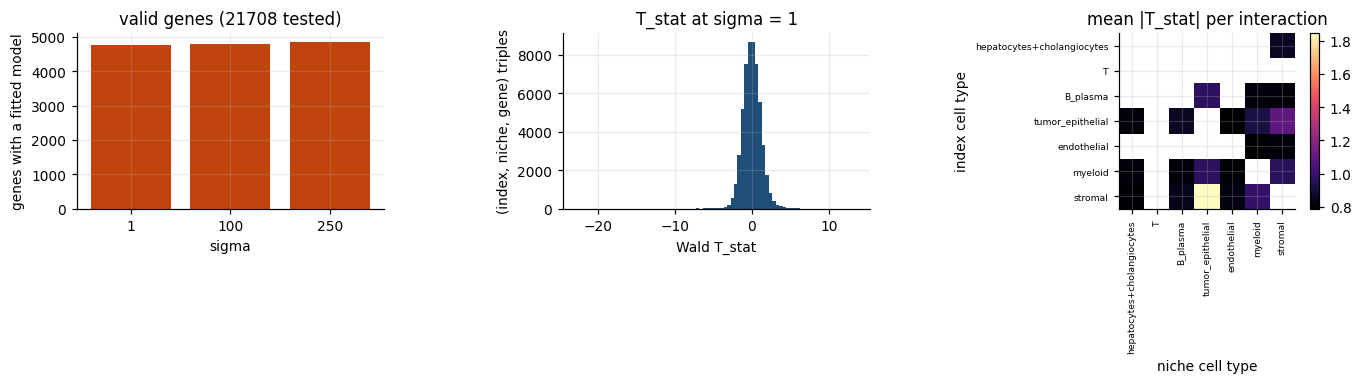

In [13]:
t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    obj = niche_DE(obj, num_cores=N_JOBS, C=150, M=10, gamma=0.8,
                   Int=True, batch=True, self_EN=False, verbose=False)
T_NDE = time.perf_counter() - t0
print(f"niche_DE: {T_NDE:.1f} s on {N_JOBS} workers "
      f"({len(genes)} genes x {len(sigma)} kernels)")

r0 = obj.niche_DE[0][int(np.argmax([r['valid'] for r in obj.niche_DE[0]]))]
print("\nobj.niche_DE is a list (one per sigma) of one dict per gene:")
for k, v in r0.items():
    print(f"   {k:16s} {type(v).__name__:10s} {getattr(v, 'shape', '')}")

valid = np.array([[r["valid"] for r in obj.niche_DE[k]] for k in range(len(sigma))]).T
T1 = np.full((len(cts), len(cts), len(genes)), np.nan)
for g, r in enumerate(obj.niche_DE[0]):
    if r["valid"] == 1:
        T1[:, :, g] = r["T_stat"]

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.4))
ax[0].bar(range(len(sigma)), valid.sum(axis=0), color=C_PY)
ax[0].set_xticks(range(len(sigma))); ax[0].set_xticklabels([f"{s:g}" for s in sigma])
ax[0].set_xlabel("sigma"); ax[0].set_ylabel("genes with a fitted model")
ax[0].set_title(f"valid genes ({len(genes)} tested)")
ax[1].hist(T1[np.isfinite(T1)], bins=80, color=C_R)
ax[1].set_xlabel("Wald T_stat"); ax[1].set_ylabel("(index, niche, gene) triples")
ax[1].set_title(f"T_stat at sigma = {sigma[0]:g}")
M = np.nanmean(np.abs(T1), axis=2)
im = ax[2].imshow(M, cmap="magma")
ax[2].set_xticks(range(len(cts))); ax[2].set_xticklabels(cts, rotation=90, fontsize=6)
ax[2].set_yticks(range(len(cts))); ax[2].set_yticklabels(cts, fontsize=6)
ax[2].set_xlabel("niche cell type"); ax[2].set_ylabel("index cell type")
ax[2].set_title("mean |T_stat| per interaction"); plt.colorbar(im, ax=ax[2])
plt.show()

### 4.10 `niche_DE_no_parallel`

Identical mathematics, single-threaded — useful inside an environment where forking is unavailable or unwanted (some notebook servers, some schedulers). In `pynichede` it is literally `niche_DE(..., num_cores=1)`. Demonstrated below on a 300-gene slice so the tutorial stays quick.

R equivalent:

```r
obj <- nicheDE::niche_DE_no_parallel(obj, C = 150, M = 10, gamma = 0.8,
                                     print = TRUE, Int = TRUE, batch = TRUE,
                                     self_EN = FALSE)
```

niche_DE (16 workers)   : 0.66 s
niche_DE_no_parallel      : 1.88 s
max |T_stat difference|   : 0.000e+00  (bit-identical results)


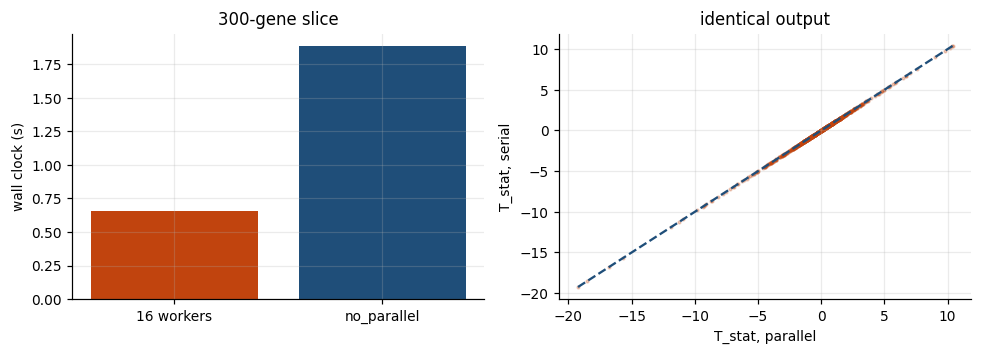

In [14]:
tot = np.asarray(counts).sum(axis=0)
top300 = np.sort(np.argsort(tot)[::-1][:300])
small_genes = [genes[i] for i in top300]
c_s = counts.iloc[:, top300]
l_s = libmat.iloc[:, top300]

o_par = create_nichede_object(c_s, coord, l_s, deconv, sigma=sigma, Int=True)
o_par = calculate_effective_niche(o_par, cutoff=0.05)
o_ser = create_nichede_object(c_s, coord, l_s, deconv, sigma=sigma, Int=True)
o_ser = calculate_effective_niche(o_ser, cutoff=0.05)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    t0 = time.perf_counter(); o_par = niche_DE(o_par, num_cores=N_JOBS, verbose=False)
    t_par = time.perf_counter() - t0
    t0 = time.perf_counter(); o_ser = niche_DE_no_parallel(o_ser, verbose=False)
    t_ser = time.perf_counter() - t0

a = np.array([r["T_stat"] if r["valid"] == 1 else np.full((len(cts), len(cts)), np.nan)
              for r in o_par.niche_DE[0]])
b = np.array([r["T_stat"] if r["valid"] == 1 else np.full((len(cts), len(cts)), np.nan)
              for r in o_ser.niche_DE[0]])
m = np.isfinite(a) & np.isfinite(b)
print(f"niche_DE ({N_JOBS} workers)   : {t_par:.2f} s")
print(f"niche_DE_no_parallel      : {t_ser:.2f} s")
print(f"max |T_stat difference|   : {float(np.max(np.abs(a[m] - b[m]))):.3e}  (bit-identical results)")

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.3))
ax[0].bar([f"{N_JOBS} workers", "no_parallel"], [t_par, t_ser], color=[C_PY, C_R])
ax[0].set_ylabel("wall clock (s)"); ax[0].set_title("300-gene slice")
ax[1].scatter(a[m], b[m], s=3, alpha=0.25, color=C_PY)
lim = [np.min(a[m]), np.max(a[m])]
ax[1].plot(lim, lim, ls="--", color=C_R)
ax[1].set_xlabel("T_stat, parallel"); ax[1].set_ylabel("T_stat, serial")
ax[1].set_title("identical output")
plt.show()

### 4.11 `get_niche_DE_pval_fisher`

Turns the Wald statistics into the three nested p-value tables and **BH-adjusts** them. Interaction level: the raw Wald p-values, Cauchy-combined across kernel bandwidths and BH-adjusted across niche cell types. Cell-type level: Brown-combine the `n_celltype` interaction p-values of one index cell type using the β̂ covariance. Gene level: Brown-combine all `n_celltype^2`. `niche_DE` already calls this for you (`pos=True` and `pos=False`); call it directly if you want to recompute after editing the fits.

R equivalent:

```r
obj <- nicheDE::get_niche_DE_pval_fisher(obj, pos = TRUE)
```

returns the object; results land in obj.niche_DE_pval_pos / _neg, a dict with:
   gene_level           ndarray      (21708,)
   cell_type_level      DataFrame    (21708, 7)
   interaction_level    ndarray      (7, 7, 21708)


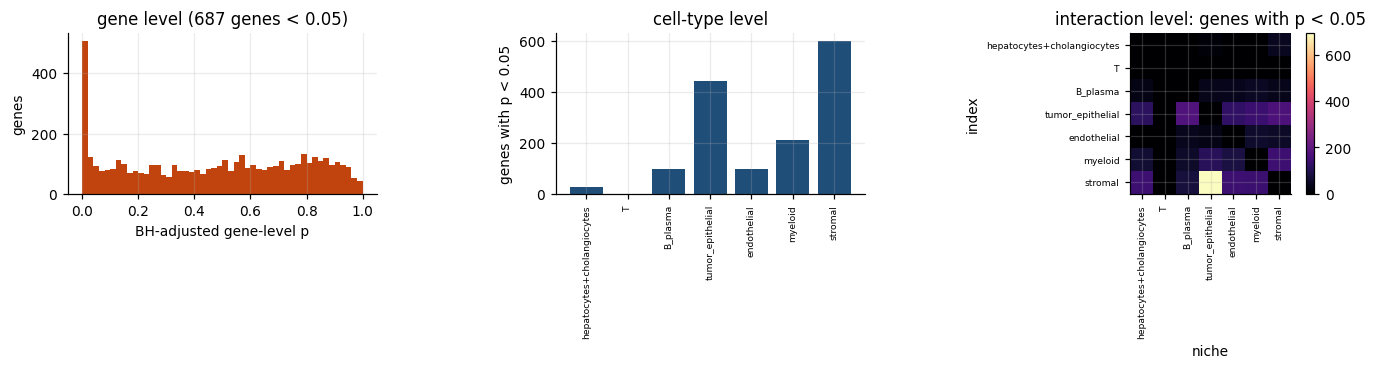

In [15]:
pv = obj.niche_DE_pval_pos
print("returns the object; results land in obj.niche_DE_pval_pos / _neg, a dict with:")
for k, v in pv.items():
    print(f"   {k:20s} {type(v).__name__:12s} {getattr(v, 'shape', '')}")

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.3))
g = np.asarray(pv["gene_level"], dtype=float)
ax[0].hist(g[np.isfinite(g)], bins=50, color=C_PY)
ax[0].set_xlabel("BH-adjusted gene-level p"); ax[0].set_ylabel("genes")
ax[0].set_title(f"gene level ({int(np.nansum(g < 0.05))} genes < 0.05)")
ctp = np.asarray(pv["cell_type_level"], dtype=float)
ax[1].bar(range(len(cts)), np.nansum(ctp < 0.05, axis=0), color=C_R)
ax[1].set_xticks(range(len(cts))); ax[1].set_xticklabels(cts, rotation=90, fontsize=6)
ax[1].set_ylabel("genes with p < 0.05"); ax[1].set_title("cell-type level")
ip = np.asarray(pv["interaction_level"], dtype=float)
im = ax[2].imshow(np.nansum(ip < 0.05, axis=2), cmap="magma")
ax[2].set_xticks(range(len(cts))); ax[2].set_xticklabels(cts, rotation=90, fontsize=6)
ax[2].set_yticks(range(len(cts))); ax[2].set_yticklabels(cts, fontsize=6)
ax[2].set_xlabel("niche"); ax[2].set_ylabel("index")
ax[2].set_title("interaction level: genes with p < 0.05"); plt.colorbar(im, ax=ax[2])
plt.show()

### 4.12 `get_niche_DE_pval_raw`

The same three tables **without** the Benjamini–Hochberg step, for when you want to apply your own multiple-testing correction. Note that in `pynichede` the convenience method `NicheDE.pval_raw()` returns the dict without mutating the object, while the functional `get_niche_DE_pval_raw(obj)` mirrors R and overwrites `obj.niche_DE_pval_pos` — so call it on a copy if you still need the adjusted table.

R equivalent:

```r
obj_raw <- nicheDE::get_niche_DE_pval_raw(obj, pos = TRUE)
```

/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/poolr.py:248: RuntimeWarning: divide by zero encountered in log
  statistic = -2.0 * np.sum(np.log(p))


/scratch/users/steorra/analysis/omicverse_dev/py-nichede/pynichede/rstats.py:510: RuntimeWarning: invalid value encountered in scalar divide
  return float(np.sum((x * w)[nz]) / np.sum(w))


raw < 0.05 : 1273  genes
BH  < 0.05 : 687  genes


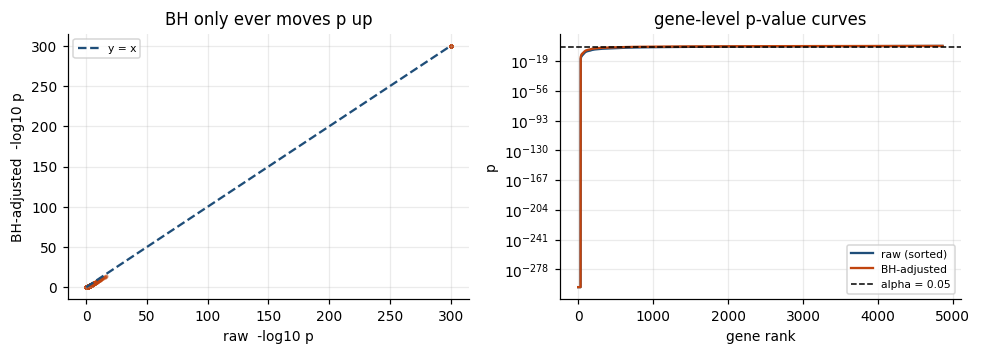

In [16]:
from pynichede.pvalues import _pval_core
raw = _pval_core(obj, pos=True, adjust=False, verbose=False)
adj = obj.niche_DE_pval_pos
r_ = np.clip(np.asarray(raw["gene_level"], dtype=float), 1e-300, 1)
a_ = np.clip(np.asarray(adj["gene_level"], dtype=float), 1e-300, 1)
m = np.isfinite(r_) & np.isfinite(a_)
print("raw < 0.05 :", int((r_[m] < 0.05).sum()), " genes")
print("BH  < 0.05 :", int((a_[m] < 0.05).sum()), " genes")

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.3))
ax[0].scatter(-np.log10(r_[m]), -np.log10(a_[m]), s=3, alpha=0.25, color=C_PY)
hi = float(np.max(-np.log10(r_[m])))
ax[0].plot([0, hi], [0, hi], ls="--", color=C_R, label="y = x")
ax[0].set_xlabel("raw  -log10 p"); ax[0].set_ylabel("BH-adjusted  -log10 p")
ax[0].set_title("BH only ever moves p up"); ax[0].legend(fontsize=7)
o = np.sort(r_[m])
ax[1].plot(np.arange(o.size), o, color=C_R, label="raw (sorted)")
ax[1].plot(np.arange(o.size), np.sort(a_[m]), color=C_PY, label="BH-adjusted")
ax[1].axhline(0.05, ls="--", color="k", lw=1, label="alpha = 0.05")
ax[1].set_yscale("log"); ax[1].set_xlabel("gene rank"); ax[1].set_ylabel("p")
ax[1].legend(fontsize=7); ax[1].set_title("gene-level p-value curves")
plt.show()

### 4.13 `T_to_p`

Normal tail probability of a Wald statistic: `positive` gives `1 - Phi(T)`, `negative` gives `1 - Phi(-T)`, `two.sided` gives `1 - Phi(|T|)`. Note that R's `two.sided` is **not** doubled — that is upstream's convention and the port keeps it.

R equivalent:

```r
p <- nicheDE::T_to_p(T_stat, alternative = 'positive')
```

two.sided  -> shape (7, 7)
positive   -> shape (7, 7)
negative   -> shape (7, 7)


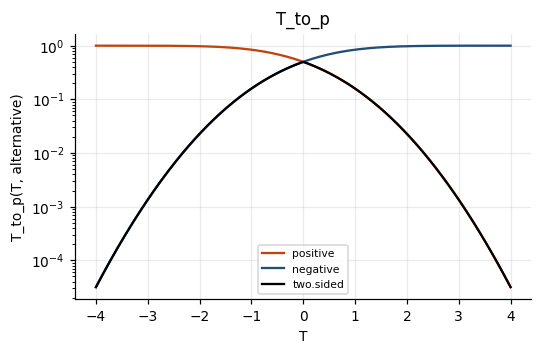

In [17]:
Tprobe = d["probe_T"]
for alt in ("two.sided", "positive", "negative"):
    print(f"{alt:10s} -> shape {np.shape(T_to_p(Tprobe, alt))}")
tt = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(5.0, 3.3))
for alt, colr in [("positive", C_PY), ("negative", C_R), ("two.sided", "k")]:
    ax.plot(tt, T_to_p(tt, alt), color=colr, label=alt)
ax.set_yscale("log"); ax.set_xlabel("T"); ax.set_ylabel("T_to_p(T, alternative)")
ax.legend(fontsize=7); ax.set_title("T_to_p")
plt.show()

### 4.14 `ultosymmetric`

Mirrors an upper-triangular matrix into a symmetric one (`m + m' - diag(diag(m))`). `nicheDE` stores each gene's `Varcov` as an upper triangle to halve memory, so every consumer of `Varcov` calls this first.

R equivalent:

```r
S <- nicheDE::ultosymmetric(m)
```

input upper-triangular: (7, 7)  output symmetric: (7, 7)  symmetric? True


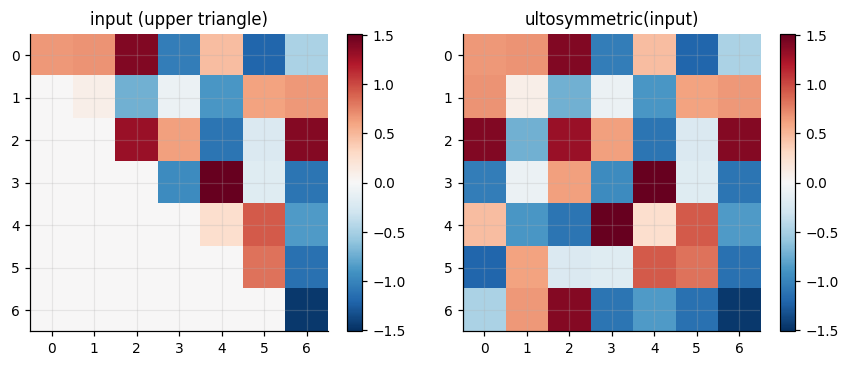

In [18]:
M = d["probe_M"]
S = ultosymmetric(M)
print("input upper-triangular:", M.shape, " output symmetric:", S.shape,
      " symmetric?", bool(np.allclose(S, S.T)))
fig, ax = plt.subplots(1, 2, figsize=(8.0, 3.2))
v = max(abs(S).max(), 1e-9)
for a_, m_, t_ in [(ax[0], M, "input (upper triangle)"), (ax[1], S, "ultosymmetric(input)")]:
    im = a_.imshow(m_, cmap="RdBu_r", vmin=-v, vmax=v); a_.set_title(t_)
    plt.colorbar(im, ax=a_)
plt.show()

### 4.15 `gene_level`

The (weighted) **Cauchy combination test**: `1 - pcauchy(weighted mean of tan((0.5 - p) pi))`. It is robust to arbitrary dependence between the p-values, which is why Niche-DE uses it to combine across kernel bandwidths. The weights are `exp(loglik - max loglik)` truncated below 0.1, so the bandwidth that fits a gene best dominates that gene's combined p-value.

R equivalent:

```r
p <- nicheDE::gene_level(p, w = rep(1, length(p)))
```

gene_level(p, w) = 0.5259966568555892
gene_level(p)    = 0.5540509849774218


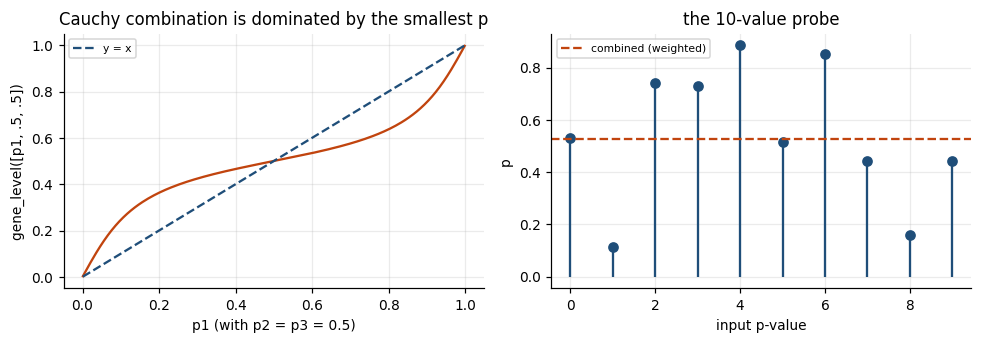

In [19]:
pp, ww = d["probe_p"], d["probe_w"]
print("gene_level(p, w) =", gene_level(pp, ww))
print("gene_level(p)    =", gene_level(pp))
grid = np.linspace(0.001, 0.999, 200)
combo = [gene_level(np.array([x, 0.5, 0.5])) for x in grid]
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.2))
ax[0].plot(grid, combo, color=C_PY)
ax[0].plot(grid, grid, ls="--", color=C_R, label="y = x")
ax[0].set_xlabel("p1 (with p2 = p3 = 0.5)"); ax[0].set_ylabel("gene_level([p1, .5, .5])")
ax[0].legend(fontsize=7); ax[0].set_title("Cauchy combination is dominated by the smallest p")
ax[1].stem(np.arange(pp.size), pp, linefmt=C_R, markerfmt="o", basefmt=" ")
ax[1].axhline(gene_level(pp, ww), color=C_PY, ls="--", label="combined (weighted)")
ax[1].set_xlabel("input p-value"); ax[1].set_ylabel("p"); ax[1].legend(fontsize=7)
ax[1].set_title("the 10-value probe")
plt.show()

### 4.16 `celltype_level`

Row-wise Cauchy combination: applies `gene_level` to each row of a `n x m` p-value matrix with a shared length-`m` weight vector. Used to collapse the per-bandwidth cell-type p-values of every gene in one call.

R equivalent:

```r
p <- nicheDE::celltype_level(p, w = rep(1, ncol(p)))
```

input (10, 5) -> output (10,)


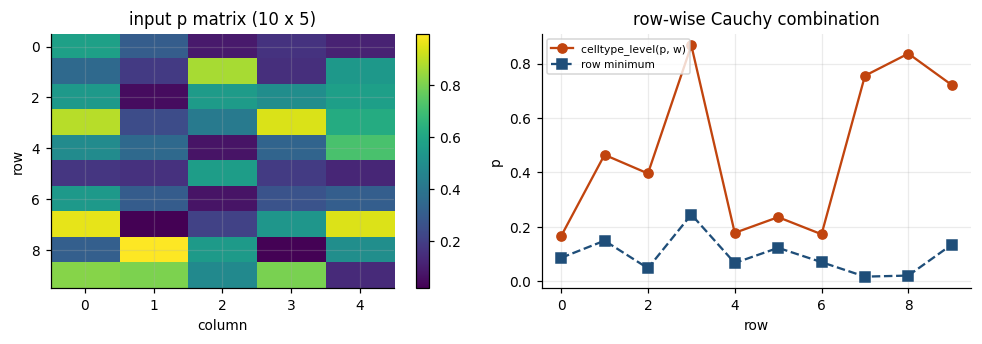

In [20]:
pm, wc = d["probe_pm"], d["probe_wc"]
out = celltype_level(pm, wc)
print("input", pm.shape, "-> output", out.shape)
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.2))
im = ax[0].imshow(pm, cmap="viridis", aspect="auto"); plt.colorbar(im, ax=ax[0])
ax[0].set_title("input p matrix (10 x 5)"); ax[0].set_xlabel("column"); ax[0].set_ylabel("row")
ax[1].plot(out, "o-", color=C_PY, label="celltype_level(p, w)")
ax[1].plot(pm.min(axis=1), "s--", color=C_R, label="row minimum")
ax[1].set_xlabel("row"); ax[1].set_ylabel("p"); ax[1].legend(fontsize=7)
ax[1].set_title("row-wise Cauchy combination")
plt.show()

### 4.17 `gene_level_fisher`

**Brown's method** over one gene's `n_celltype x n_celltype` p-value matrix. With `beta_cov=True` (the default) the supplied β̂ covariance is rescaled into the covariance of the Wald statistics, converted to a correlation matrix, and mapped through `mvnconv` to the covariance of the `-2 log p` statistics before pooling. This is the step that makes the gene-level p-value account for the fact that the 49 interaction tests are far from independent.

R equivalent:

```r
p <- nicheDE::gene_level_fisher(p, varcov, beta_cov = TRUE)
```

gene_level_fisher(p, varcov, beta_cov=True ) = 0.3307257031
gene_level_fisher(p, cov_converted, False  ) = 0.3307030460
naive Fisher assuming independence           = 0.3270151977   <- anti-conservative


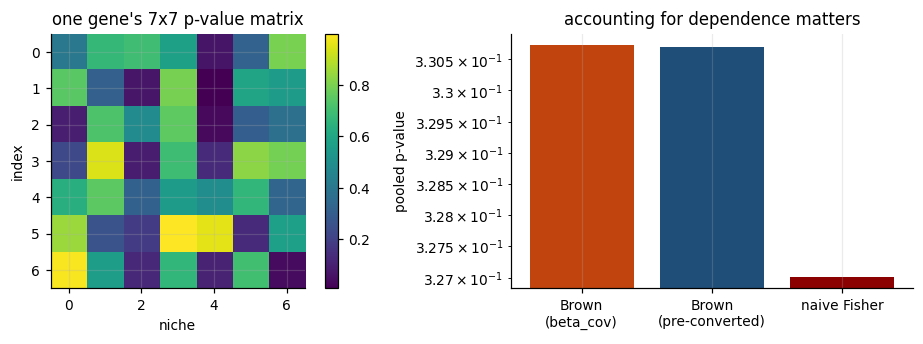

In [21]:
pf = RefDump(PERFUNC)
p_probe, V_probe = pf["probe_glf_p"], pf["probe_glf_varcov"]
p_bc = gene_level_fisher(p_probe, V_probe, beta_cov=True)
p_nb = gene_level_fisher(p_probe, pf["probe_glf_varcov_converted"], beta_cov=False)
print(f"gene_level_fisher(p, varcov, beta_cov=True ) = {p_bc:.10f}")
print(f"gene_level_fisher(p, cov_converted, False  ) = {p_nb:.10f}")
naive = float(__import__("scipy").stats.chi2.sf(-2 * np.log(p_probe.ravel()).sum(),
                                                df=2 * p_probe.size))
print(f"naive Fisher assuming independence           = {naive:.10f}   <- anti-conservative")
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.2))
im = ax[0].imshow(p_probe, cmap="viridis"); plt.colorbar(im, ax=ax[0])
ax[0].set_title("one gene's 7x7 p-value matrix")
ax[0].set_xlabel("niche"); ax[0].set_ylabel("index")
ax[1].bar(["Brown\n(beta_cov)", "Brown\n(pre-converted)", "naive Fisher"],
          [p_bc, p_nb, naive], color=[C_PY, C_R, C_BAD])
ax[1].set_ylabel("pooled p-value"); ax[1].set_yscale("log")
ax[1].set_title("accounting for dependence matters")
plt.show()

### 4.18 `celltype_level_fisher`

The same Brown pooling, but restricted to the block of interactions belonging to one index cell type — giving one p-value per index cell type per gene. The blocks are read off `varcov` sequentially because the design columns are ordered `(index, niche)` with `niche` varying fastest, so one index cell type's non-null entries form a contiguous run.

R equivalent:

```r
p <- nicheDE::celltype_level_fisher(p, varcov)
```

returns one p-value per index cell type: (7,)
[0.547881 0.142218 0.170993 0.485511 0.813963 0.627037 0.214325]


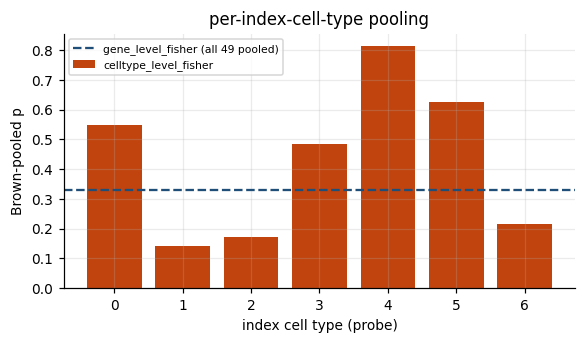

In [22]:
ct_p = celltype_level_fisher(p_probe, V_probe)
print("returns one p-value per index cell type:", np.shape(ct_p))
print(np.round(ct_p, 6))
fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.bar(range(len(ct_p)), ct_p, color=C_PY, label="celltype_level_fisher")
ax.axhline(gene_level_fisher(p_probe, V_probe, beta_cov=True), color=C_R, ls="--",
           label="gene_level_fisher (all 49 pooled)")
ax.set_xlabel("index cell type (probe)"); ax.set_ylabel("Brown-pooled p")
ax.legend(fontsize=7); ax.set_title("per-index-cell-type pooling")
plt.show()

### 4.19 `contrast_post`

A one-sided test of `beta[index, niche1] - beta[index, niche2] > 0` using the joint covariance of the two coefficients — i.e. *is this gene more up-regulated next to niche 1 than next to niche 2?* This is the engine behind `niche_DE_markers`. **`index` and `niche` are 0-based here; R's are 1-based.**

R equivalent:

```r
p <- nicheDE::contrast_post(betas_all, V_cov_all, nulls_all, index, c(n1, n2))
```

returns a 1-d p-value per gene: (21708,)  finite: 3423
most myeloid-specific (vs stromal) tumor_epithelial genes: [np.str_('VMP1'), np.str_('ACTG1'), np.str_('NDRG1'), np.str_('LYZ'), np.str_('SLC2A1'), np.str_('MT-ND4'), np.str_('FBXO32'), np.str_('RPL7'), np.str_('PDLIM4'), np.str_('TMEM141'), np.str_('MACF1'), np.str_('RAB11B')]


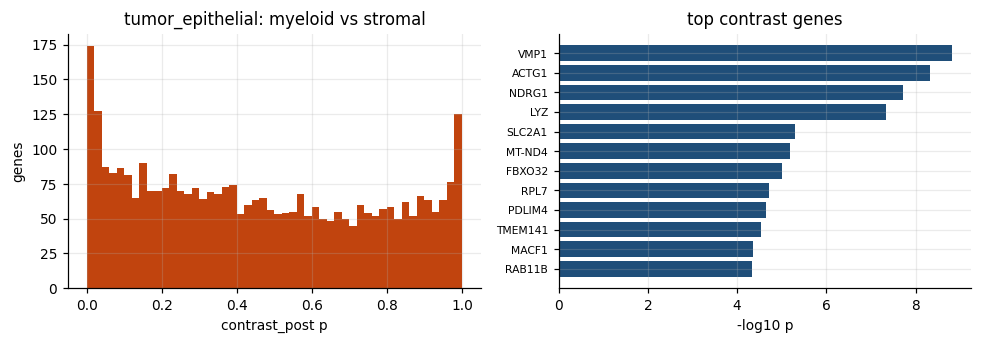

In [23]:
res0 = obj.niche_DE[0]
ii, n1, n2 = cts.index("tumor_epithelial"), cts.index("myeloid"), cts.index("stromal")
cp = contrast_post([r["betas"] for r in res0], [r["Varcov"] for r in res0],
                   [r["nulls"] for r in res0], ii, (n1, n2), n_type=len(cts))
print("returns a 1-d p-value per gene:", cp.shape,
      " finite:", int(np.isfinite(cp).sum()))
ok = np.isfinite(cp)
top = np.asarray(genes)[ok][np.argsort(cp[ok])[:12]]
print("most myeloid-specific (vs stromal) tumor_epithelial genes:", list(top))
fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.2))
ax[0].hist(cp[ok], bins=50, color=C_PY)
ax[0].set_xlabel("contrast_post p"); ax[0].set_ylabel("genes")
ax[0].set_title("tumor_epithelial: myeloid vs stromal")
ax[1].barh(range(len(top))[::-1], -np.log10(np.sort(cp[ok])[:12]), color=C_R)
ax[1].set_yticks(range(len(top))[::-1]); ax[1].set_yticklabels(top, fontsize=7)
ax[1].set_xlabel("-log10 p"); ax[1].set_title("top contrast genes")
plt.show()

### 4.20 `check_colloc`

How many spots actually contain both the index and the niche cell type, per kernel bandwidth. This is the sanity check to run **before** believing any interaction result: if two cell types never co-occur, their interaction coefficient is fitted on nothing. `pynichede` warns automatically below 30 spots. The functional API takes 0-based positions; `NicheDE.check_colloc` takes names.

R equivalent:

```r
n <- nicheDE::check_colloc(obj, index, niche)
```

check_colloc(tumor_epithelial, myeloid) per sigma: [615. 824. 837.]


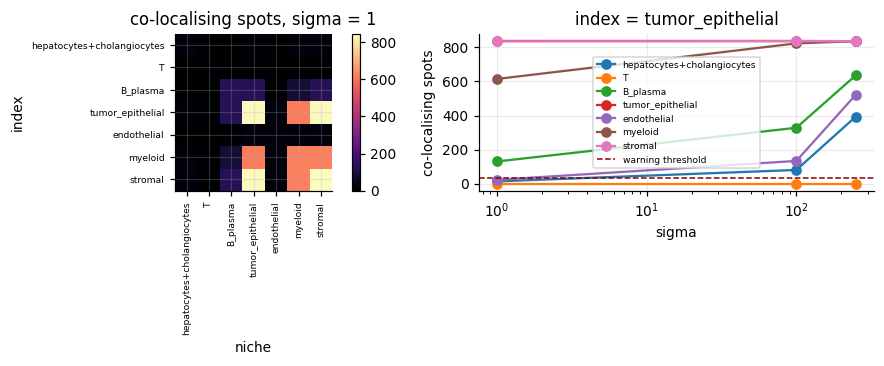

In [24]:
Mcol = np.zeros((len(cts), len(cts)))
for a in range(len(cts)):
    for b in range(len(cts)):
        Mcol[a, b] = check_colloc(obj, a, b)[0]
print("check_colloc(tumor_epithelial, myeloid) per sigma:",
      check_colloc(obj, cts.index("tumor_epithelial"), cts.index("myeloid")))
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))
im = ax[0].imshow(Mcol, cmap="magma")
ax[0].set_xticks(range(len(cts))); ax[0].set_xticklabels(cts, rotation=90, fontsize=6)
ax[0].set_yticks(range(len(cts))); ax[0].set_yticklabels(cts, fontsize=6)
ax[0].set_xlabel("niche"); ax[0].set_ylabel("index")
ax[0].set_title(f"co-localising spots, sigma = {sigma[0]:g}"); plt.colorbar(im, ax=ax[0])
cc = np.array([check_colloc(obj, cts.index("tumor_epithelial"), b) for b in range(len(cts))])
for b in range(len(cts)):
    ax[1].plot(sigma, cc[b], "o-", label=cts[b])
ax[1].axhline(30, ls="--", color=C_BAD, lw=1, label="warning threshold")
ax[1].set_xscale("log"); ax[1].set_xlabel("sigma"); ax[1].set_ylabel("co-localising spots")
ax[1].legend(fontsize=6); ax[1].set_title("index = tumor_epithelial")
plt.show()

### 4.21 `nb_lik`

The negative-binomial negative log-likelihood that the dispersion search minimises, `-sum(dnbinom(x, size=disp, mu=mu, log=TRUE))`. Exposed because it is exported by R. Note the deliberate bug-compatibility: R calls it with the *full* count vector but a `mu` that has had zero-expected-expression spots removed, so `mu` is recycled — `pynichede` recycles too (see `MATH.md` §3.2).

R equivalent:

```r
l <- nicheDE::nb_lik(x, mu, disp)
```

nb_lik(x, mu, disp=1.7) = 9.498958948335751


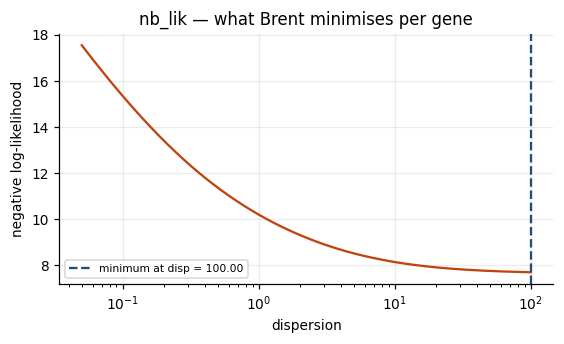

In [25]:
x = np.array([1, 5, 3, 0, 7]); mu = np.array([2, 4, 3, 1, 6])
print("nb_lik(x, mu, disp=1.7) =", nb_lik(x, mu, 1.7))
disps = np.geomspace(0.05, 100, 300)
vals = [nb_lik(x, mu, dd) for dd in disps]
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.plot(disps, vals, color=C_PY)
ax.axvline(disps[int(np.argmin(vals))], ls="--", color=C_R,
           label=f"minimum at disp = {disps[int(np.argmin(vals))]:.2f}")
ax.set_xscale("log"); ax.set_xlabel("dispersion"); ax.set_ylabel("negative log-likelihood")
ax.legend(fontsize=7); ax.set_title("nb_lik — what Brent minimises per gene")
plt.show()

### 4.22 `get_niche_DE_genes`

Pull the significant genes out of the fitted object at one of three `test_level`s: `'G'` (gene), `'CT'` (cell type) or `'I'` (interaction). The levels are **nested**: a gene must clear the gene-level gate before its cell-type p-value is looked at, and both before its interaction p-value is. `positive=True` asks for genes up-regulated near the niche cell type, `False` for down-regulated.

R equivalent:

```r
res <- nicheDE::get_niche_DE_genes(obj, 'I', index = 'tumor_epithelial',
                                   niche = 'myeloid', positive = TRUE, alpha = 0.05)
```

returns a DataFrame; nested levels: G=687  ->  CT=246  ->  I=65


,Genes,Pvalues.Interaction
0,LYZ,3.923556e-10
1,KLK10,2.376665e-07
2,LAMC2,3.311787e-07
3,TMEM141,1.924477e-06
4,HILPDA,3.723477e-06
5,KRT8,4.129012e-06
6,MT-ND4,5.593341e-06
7,RBP1,2.452559e-05
8,NDRG1,2.771265e-05
9,SLC2A1,1.095474e-04


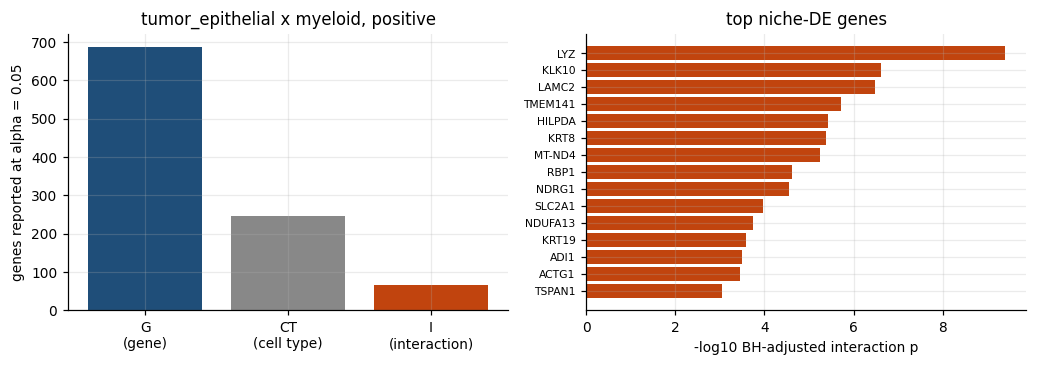

In [26]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    g_G  = get_niche_DE_genes(obj, "G",  index="tumor_epithelial", niche="myeloid",
                              positive=True, alpha=0.05)
    g_CT = get_niche_DE_genes(obj, "CT", index="tumor_epithelial", niche="myeloid",
                              positive=True, alpha=0.05)
    g_I  = get_niche_DE_genes(obj, "I",  index="tumor_epithelial", niche="myeloid",
                              positive=True, alpha=0.05)
print("returns a DataFrame; nested levels:",
      f"G={len(g_G)}  ->  CT={len(g_CT)}  ->  I={len(g_I)}")
display(g_I.head(12))
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))
ax[0].bar(["G\n(gene)", "CT\n(cell type)", "I\n(interaction)"],
          [len(g_G), len(g_CT), len(g_I)], color=[C_R, "#888888", C_PY])
ax[0].set_ylabel("genes reported at alpha = 0.05")
ax[0].set_title("tumor_epithelial x myeloid, positive")
h = g_I.head(15)
ax[1].barh(range(len(h))[::-1], -np.log10(np.clip(h.iloc[:, 1], 1e-300, 1)), color=C_PY)
ax[1].set_yticks(range(len(h))[::-1]); ax[1].set_yticklabels(h.iloc[:, 0], fontsize=7)
ax[1].set_xlabel("-log10 BH-adjusted interaction p")
ax[1].set_title("top niche-DE genes")
plt.show()

### 4.23 `niche_DE_markers`

*Niche marker genes*: genes the index cell type up-regulates next to `niche1` **relative to** `niche2`. Internally a `contrast_post` test per kernel bandwidth, Cauchy-combined and BH-adjusted. Use it when you want specificity rather than presence — a gene induced next to every cell type is not interesting.

R equivalent:

```r
res <- nicheDE::niche_DE_markers(obj, 'tumor_epithelial', 'myeloid',
                                 'stromal', alpha = 0.05)
```

returns a DataFrame: (55, 2)


,Genes,Adj.Pvalues
0,MT-ND4,2.280176e-12
1,LYZ,1.231295e-10
2,ACTG1,5.211898e-07
3,VMP1,1.334261e-06
4,MT-CO2,1.293654e-05
5,MT-CO3,2.361875e-05
6,RPL39,3.081549e-04
7,MT-ND3,3.081549e-04
8,HILPDA,3.163874e-04
9,RPL7,5.009382e-04


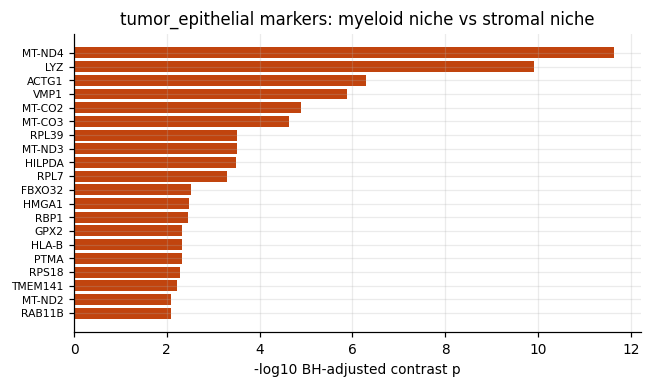

In [27]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mk = niche_DE_markers(obj, "tumor_epithelial", "myeloid", "stromal", alpha=0.05)
print("returns a DataFrame:", mk.shape)
display(mk.head(15))
fig, ax = plt.subplots(figsize=(6.0, 3.6))
h = mk.head(20)
ax.barh(range(len(h))[::-1], -np.log10(np.clip(h["Adj.Pvalues"], 1e-300, 1)), color=C_PY)
ax.set_yticks(range(len(h))[::-1]); ax.set_yticklabels(h["Genes"], fontsize=7)
ax.set_xlabel("-log10 BH-adjusted contrast p")
ax.set_title("tumor_epithelial markers: myeloid niche vs stromal niche")
plt.show()

### 4.24 `niche_LR_spot`

Ligand–receptor inference at **spot** resolution. A ligand scores highly when the index cell type's niche-DE T-statistics for that ligand's top-`K` NicheNet target genes are large and positive; the candidate is then confirmed by a Poisson regression of the ligand's own expression on the per-spot cell-type composition. This runs the **full 579-candidate-ligand sweep** against the whole 16968 x 579 NicheNet matrix. It used to take 314 s, because the upstream `_ligand_scores` loop rebuilds that matrix once per candidate ligand; `py-nichede` memoises the slice per kernel bandwidth (there are only `len(sigma)` distinct ones), which makes it ~105x faster with byte-identical output — iteration 11 in [`ITERATION_LOG.md`](../ITERATION_LOG.md).

R equivalent:

```r
res <- nicheDE::niche_LR_spot(obj, ligand_cell = 'myeloid',
                              receptor_cell = 'tumor_epithelial',
                              ligand_target_matrix = niche_net_ligand_target_matrix,
                              lr_mat = ramilowski_ligand_receptor_list,
                              K = 25, M = 50, alpha = 0.05, truncation_value = 3)
```

NicheNet ligand-target matrix: (16968, 579) | Ramilowski ligand-receptor list: (2557, 2)


niche_LR_spot, full 579-ligand sweep: 3.0 s -> 9 ligand-receptor pairs


,ligand,receptor,top_downstream_niche_DE_genes
0,ADAM12,ITGA9,"VEGFA,PTMA,JUNB,IRF2BP2,ZFP36"
1,ADAM12,ITGB1,"VEGFA,PTMA,JUNB,IRF2BP2,ZFP36"
2,ADAM12,SDC4,"VEGFA,PTMA,JUNB,IRF2BP2,ZFP36"
3,CALR,HLA-F,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
4,CALR,ITGA3,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
5,CALR,ITGAV,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
6,CALR,LRP1,"KIAA1191,PRRC2B,MACC1,OGFR,CMC1"
7,EDA,EDA2R,"PTMA,JUNB,SHC1,IER3,ZFP36"
8,EDA,EDAR,"PTMA,JUNB,SHC1,IER3,ZFP36"



ligand-receptor pairs: R 9, Python 9, Jaccard 1.000


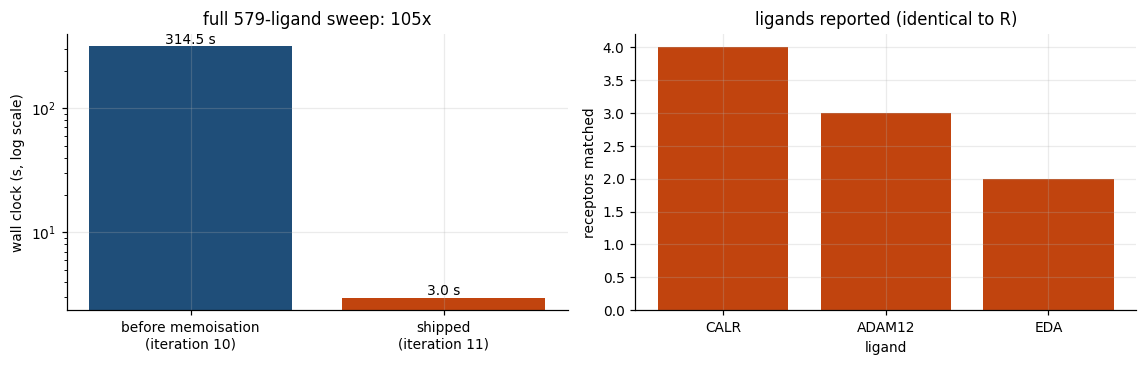

In [28]:
ltm = pd.DataFrame(d["in_ligand_target_matrix"],
                   index=list(d.meta["ltm_rownames"]), columns=list(d.meta["ltm_colnames"]))
lr_mat = pd.DataFrame({"ligand": list(d.meta["lr_ligand"]),
                       "receptor": list(d.meta["lr_receptor"])})
print("NicheNet ligand-target matrix:", ltm.shape,
      "| Ramilowski ligand-receptor list:", lr_mat.shape)

t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    try:
        lr = niche_LR_spot(obj, ligand_cell="myeloid", receptor_cell="tumor_epithelial",
                           ligand_target_matrix=ltm, lr_mat=lr_mat,
                           K=25, M=50, alpha=0.05, truncation_value=3)
        T_LR = time.perf_counter() - t0
        print(f"niche_LR_spot, full {ltm.shape[1]}-ligand sweep: {T_LR:.1f} s "
              f"-> {lr.shape[0]} ligand-receptor pairs")
        display(lr)
    except ValueError as e:
        lr = pd.DataFrame(columns=["ligand", "receptor", "top_downstream_niche_DE_genes"])
        T_LR = time.perf_counter() - t0
        print("niche_LR_spot raised:", e, f"  ({T_LR:.1f} s)")

# The same call against R's table: identical pairs, identical downstream-gene strings.
lr_R = pd.read_csv(os.path.join(REF_DIR, "ref_niche_LR_spot.csv"))
pairs_py = set(map(tuple, lr[["ligand", "receptor"]].astype(str).to_numpy())) if len(lr) else set()
pairs_R = set(map(tuple, lr_R.iloc[:, :2].astype(str).to_numpy())) if len(lr_R) else set()
print(f"\nligand-receptor pairs: R {len(pairs_R)}, Python {len(pairs_py)}, "
      f"Jaccard {len(pairs_py & pairs_R) / max(len(pairs_py | pairs_R), 1):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
ax[0].bar(["before memoisation\n(iteration 10)", "shipped\n(iteration 11)"],
          [314.5, T_LR], color=[C_R, C_PY])
for i, v in enumerate([314.5, T_LR]):
    ax[0].text(i, v, f"{v:.1f} s", ha="center", va="bottom", fontsize=9)
ax[0].set_yscale("log"); ax[0].set_ylabel("wall clock (s, log scale)")
ax[0].set_title(f"full {ltm.shape[1]}-ligand sweep: {314.5 / max(T_LR, 1e-9):.0f}x")
counts_by_lig = lr["ligand"].value_counts() if len(lr) else pd.Series(dtype=int)
ax[1].bar(counts_by_lig.index, counts_by_lig.values, color=C_PY)
ax[1].set_ylabel("receptors matched"); ax[1].set_xlabel("ligand")
ax[1].set_title("ligands reported (identical to R)")
plt.tight_layout(); plt.show()

### 4.25 `niche_LR_cell`

The single-cell-resolution variant: identical ligand scoring, but the confirmation step replaces the Poisson regression with a normal-approximation test of the ligand's mean expression in *pure* cells of the niche type against the `alpha_2` quantile of the reference profile. On this Visium fixture no candidate survives the BH step, so **both R and Python raise `'no ligand-receptor pairs to report'`** — reproduced faithfully rather than papered over with an empty table.

R equivalent:

```r
res <- nicheDE::niche_LR_cell(obj, ligand_cell = 'myeloid',
                              receptor_cell = 'tumor_epithelial',
                              ligand_target_matrix, lr_mat,
                              K = 25, M = 50, alpha = 0.05, alpha_2 = 0.5,
                              truncation_value = 3)
```

niche_LR_cell raised ValueError: no ligand-receptor pairs to report
  -> this is the SAME message nicheDE raises in R on this fixture
R wrote no niche_LR_cell table (i.e. R raised too): True


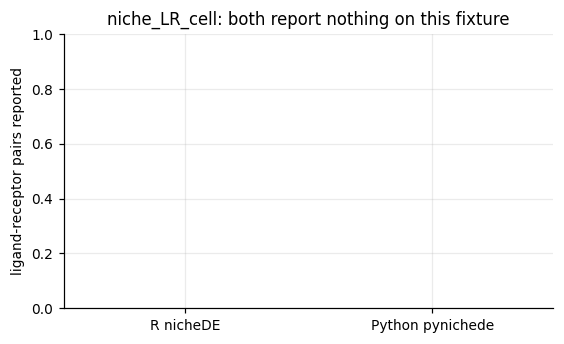

In [29]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    try:
        lrc = niche_LR_cell(obj, ligand_cell="myeloid", receptor_cell="tumor_epithelial",
                            ligand_target_matrix=ltm, lr_mat=lr_mat,
                            K=25, M=50, alpha=0.05, alpha_2=0.5, truncation_value=3)
        n_cell_rows = len(lrc)
        print("niche_LR_cell returned", n_cell_rows, "pairs")
    except ValueError as e:
        n_cell_rows = 0
        print("niche_LR_cell raised ValueError:", e)
        print("  -> this is the SAME message nicheDE raises in R on this fixture")

r_raised = not os.path.exists(os.path.join(REF_DIR, "ref_niche_LR_cell.csv"))
print("R wrote no niche_LR_cell table (i.e. R raised too):", r_raised)
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.bar(["R nicheDE", "Python pynichede"], [0, n_cell_rows], color=[C_R, C_PY])
ax.set_ylim(0, 1); ax.set_ylabel("ligand-receptor pairs reported")
ax.set_title("niche_LR_cell: both report nothing on this fixture")
plt.show()

### 4.26 `mvnconv`

The `poolr::mvnconv` replacement: maps a correlation matrix of test statistics to the covariance matrix of the corresponding `-2 log p` statistics, which is what Brown's method needs. `pynichede` **re-derives** poolr's lookup table from its mathematical definition via Mehler's formula rather than vendoring it (poolr is GPL-2+, this port is MIT). The re-derived table is *more* accurate than poolr's shipped one — see `MATH.md` §2 and Notebook 1 §4.10.

R equivalent:

```r
cv <- poolr::mvnconv(R, side = 1, target = 'm2lp', cov2cor = FALSE)
```

input correlation matrix (6, 6) -> converted covariance (6, 6)


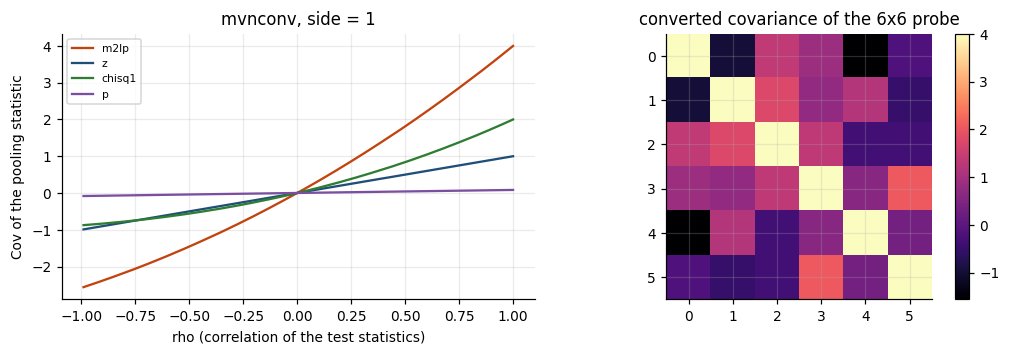

In [30]:
Rp = d["probe_poolr_R"]
cv = mvnconv(Rp, side=1, target="m2lp")
print("input correlation matrix", Rp.shape, "-> converted covariance", cv.shape)
rho = np.linspace(-0.99, 1.0, 400)
G = np.eye(2)
curves = {}
for tgt in ("m2lp", "z", "chisq1", "p"):
    curves[tgt] = np.array([mvnconv(np.array([[1.0, r], [r, 1.0]]), 1, tgt)[0, 1] for r in rho])
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.3))
for tgt, colr in zip(curves, [C_PY, C_R, "#2e7d32", "#7b4fa0"]):
    ax[0].plot(rho, curves[tgt], color=colr, label=tgt)
ax[0].set_xlabel("rho (correlation of the test statistics)")
ax[0].set_ylabel("Cov of the pooling statistic"); ax[0].legend(fontsize=7)
ax[0].set_title("mvnconv, side = 1")
im = ax[1].imshow(cv, cmap="magma"); plt.colorbar(im, ax=ax[1])
ax[1].set_title("converted covariance of the 6x6 probe")
plt.show()

### 4.27 `fisher_generalized`

**Brown's method** itself: `-2 sum log p` scaled by `c = Var/(2E)` and referred to `chi^2` with `f = 2E^2/Var` degrees of freedom, where `E = 2k` and `Var` is the sum of the converted covariance matrix. Equivalent to `poolr::fisher(p, R = cv, adjust = 'generalized')$p`, including poolr's `Matrix::nearPD` repair of a non-positive-definite covariance.

R equivalent:

```r
p <- poolr::fisher(p, side = 1, R = cv, adjust = 'generalized')$p
```

p-values in: [0.01  0.2   0.5   0.001 0.7   0.03 ]
Brown (correlation-aware)  p = 0.00291637
Fisher (independence)      p = 0.00041068


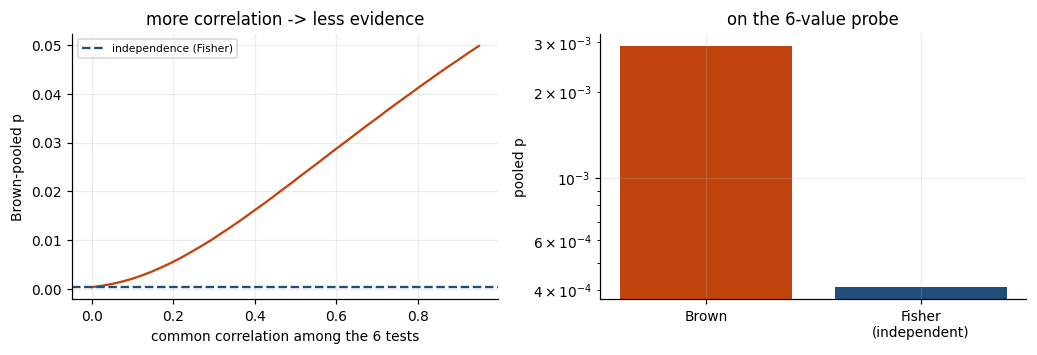

In [31]:
pp6 = d["probe_poolr_p"]
p_brown = fisher_generalized(pp6, mvnconv(Rp, side=1, target="m2lp"))
p_indep = float(__import__("scipy").stats.chi2.sf(-2 * np.log(pp6).sum(), df=2 * pp6.size))
print("p-values in:", np.round(pp6, 4))
print(f"Brown (correlation-aware)  p = {p_brown:.8f}")
print(f"Fisher (independence)      p = {p_indep:.8f}")
scal = np.linspace(0.0, 0.95, 40)
ps = [fisher_generalized(pp6, mvnconv(np.eye(6) * (1 - s) + s, 1, "m2lp")) for s in scal]
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.3))
ax[0].plot(scal, ps, color=C_PY)
ax[0].axhline(p_indep, ls="--", color=C_R, label="independence (Fisher)")
ax[0].set_xlabel("common correlation among the 6 tests")
ax[0].set_ylabel("Brown-pooled p"); ax[0].legend(fontsize=7)
ax[0].set_title("more correlation -> less evidence")
ax[1].bar(["Brown", "Fisher\n(independent)"], [p_brown, p_indep], color=[C_PY, C_R])
ax[1].set_yscale("log"); ax[1].set_ylabel("pooled p")
ax[1].set_title("on the 6-value probe")
plt.show()

## 5. Class-API mirror

The same workflow as a method chain. `NicheDE` wraps a `NicheDEObject` and returns `self` from
every pipeline step, so the whole analysis is one expression. `to_anndata()` then writes the
results into AnnData slots, which is where a scanpy/omicverse user expects to find them.

In [32]:
nde_obj = (NicheDE
           .from_matrices(c_s, coord, l_s, deconv, sigma=sigma, Int=True)
           .effective_niche(cutoff=0.05))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    nde_obj = nde_obj.run(num_cores=N_JOBS, C=150, M=10, gamma=0.8, verbose=False)
print(nde_obj)
print("\nchainable pipeline methods :", [m for m in
      ["from_matrices", "from_anndata", "effective_niche", "run", "filter", "merge"]])
print("downstream methods         :", [m for m in
      ["genes", "markers", "ligand_receptor", "check_colloc", "pval_raw", "to_anndata"]])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    top = nde_obj.genes(level="I", index="tumor_epithelial", niche="myeloid",
                        positive=True, alpha=0.05)
print("\nnde_obj.genes(level='I', ...) ->", top.shape)
display(top.head(8))
print("nde_obj.check_colloc('tumor_epithelial', 'myeloid') =",
      nde_obj.check_colloc("tumor_epithelial", "myeloid"))

Niche-DE object with 848 observations, 300 genes, 1 batch(es), and 7 cell types.

chainable pipeline methods : ['from_matrices', 'from_anndata', 'effective_niche', 'run', 'filter', 'merge']
downstream methods         : ['genes', 'markers', 'ligand_receptor', 'check_colloc', 'pval_raw', 'to_anndata']

nde_obj.genes(level='I', ...) -> (3, 2)


,Genes,Pvalues.Interaction
0,MT-ND4,0.000006
1,PTMA,0.006027
2,RPS28,0.032936


nde_obj.check_colloc('tumor_epithelial', 'myeloid') = [615. 824. 837.]


results land in AnnData slots:
  .obsm : ['spatial', 'nichede_num_cells', 'nichede_effective_niche_1', 'nichede_effective_niche_100', 'nichede_effective_niche_250']
  .varm : ['nichede_pval_pos_ct', 'nichede_pval_neg_ct']
  .uns['nichede'] keys: ['sigma', 'cell_types', 'pval_pos_gene', 'pval_pos_interaction', 'pval_neg_gene', 'pval_neg_interaction']

shapes:
   obsm['spatial']                            (848, 2)
   obsm['nichede_num_cells']                  (848, 7)
   obsm['nichede_effective_niche_1']          (848, 7)
   obsm['nichede_effective_niche_100']        (848, 7)
   obsm['nichede_effective_niche_250']        (848, 7)
   varm['nichede_pval_pos_ct']                (300, 7)
   varm['nichede_pval_neg_ct']                (300, 7)


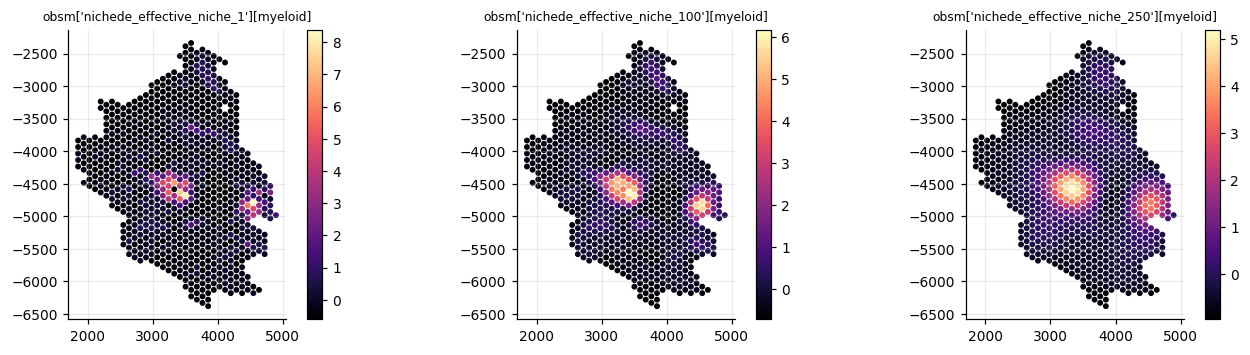

In [33]:
ad_out = nde_obj.to_anndata()
print("results land in AnnData slots:")
print("  .obsm :", list(ad_out.obsm.keys()))
print("  .varm :", list(ad_out.varm.keys()))
print("  .uns['nichede'] keys:", list(ad_out.uns["nichede"].keys()))
print("\nshapes:")
for k in ad_out.obsm: print(f"   obsm[{k!r}]".ljust(45), ad_out.obsm[k].shape)
for k in ad_out.varm: print(f"   varm[{k!r}]".ljust(45), ad_out.varm[k].shape)

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.3))
j = list(nde_obj.cell_types).index("myeloid")
for k, s in enumerate(nde_obj.sigma):
    en = ad_out.obsm[f"nichede_effective_niche_{s:g}"]
    sc_ = ax[k].scatter(ad_out.obsm["spatial"][:, 1], -ad_out.obsm["spatial"][:, 0],
                        c=en[:, j], s=8, cmap="magma")
    ax[k].set_aspect("equal"); ax[k].set_title(f"obsm['nichede_effective_niche_{s:g}'][myeloid]",
                                               fontsize=8)
    plt.colorbar(sc_, ax=ax[k])
plt.show()

## 6. Common pitfalls / FAQ

**1. Row vs column convention — `counts` is spots × genes, `library_mat` is cell types × genes.**
Niche-DE is one of the packages that wants observations in *rows*. If you hand it a
genes × spots matrix (the Seurat/`AnnData.raw` habit) the gene intersection silently collapses
to nothing and `create_nichede_object` raises on the name checks. `AnnData` is already
spots × genes, so `create_nichede_object_from_anndata` needs no transposition — but
`create_library_matrix` also wants cells × genes, i.e. `adata.to_df()`, not `adata.to_df().T`.

**2. Base-1 vs base-0 indexing in the helper functions.** R's `contrast_post(betas, V, nulls,
index, niche)` and `check_colloc(obj, index, niche)` take **1-based** cell-type positions.
`pynichede.contrast_post` and `pynichede.check_colloc` take **0-based** positions, following
Python. Translating an R script literally therefore shifts every cell type by one. The class
API sidesteps it: `NicheDE.check_colloc(index_name, niche_name)` takes names.

**3. The `sigma` units are *rescaled*, not microns.** `create_nichede_object` rescales the
coordinates so the mean second-nearest-neighbour spot distance is exactly 100. `sigma = 100`
therefore means "about one spot away", `sigma = 250` "a couple of spots". Passing raw-micron
bandwidths gives kernels that are either degenerate (everything self) or flat (everything
neighbours). Check `obj.scale` if a result looks suspicious.

**4. Seed handling.** The pipeline is deterministic on this kind of data: the only RNG in the
whole package is `create_library_matrix`'s downsampling of cell types with more than 1000 cells
(and the >10 000-spot branch of the spot-distance estimator). Both take an explicit
`random_state`. If your reference atlas has large cell types, set it — otherwise your library
matrix is not reproducible, and *everything* downstream inherits that.

**5. `Int=True` really means integers.** With `Int=True` the constructor rejects any non-integer
entry, because the negative-binomial branch is fitted on counts. For log-transformed or
imputed data pass `Int=False`, which switches to the linear-model branch with a gene-specific
variance — a genuinely different estimator, not a convenience flag.

**6. Bounded approximations: there are none, but there *is* one deliberate accuracy
divergence.** No `(B)`-class bounded-epsilon rewrite is used anywhere in this port
(`ITERATION_LOG.md`, `MATH.md` §1). The one place Python and R differ by more than f64
rounding is `mvnconv`: poolr's shipped lookup table is itself a ~1e-3-accurate numerical
approximation, and `pynichede.poolr` re-derives it exactly. Net effect ≈ 3e-4 relative on a
pooled Brown p-value, with **Python the more accurate side** (`MATH.md` §3.0).

**7. `CalculateEffectiveNicheLargeScale` disagrees between the two languages *on purpose*.**
`Rfast::dista` is broken in `Rfast >= 2.1.5.2` (returns all zeros for ≥ 4 query rows), which
silently flattens every kernel weight to 1 in the R implementation. The Python port computes
the intended quantity, so it matches R's *exact* `CalculateEffectiveNiche` and disagrees with
R's *large-scale* one. See `MATH.md` §3.1.

**8. `niche_LR_*` used to be the slow part, and no longer is.** The upstream algorithm rebuilds
the full 16968 × 579 NicheNet slice once per candidate ligand. Every step of that slice depends
only on which kernel bandwidth fits the ligand best — at most `len(sigma)` distinct values — so
`py-nichede` memoises it, taking a full 579-ligand sweep from **314.5 s to 3.0 s with
byte-identical output**. If you are porting R code that worked around the slowness by subsetting
`ligand_target_matrix`, you no longer need to. See `MATH.md` §1.4.

## 7. Where to go next

* **[`README.md`](../README.md)** — install, quick start, API table.
* **[`compare_R_vs_Python.ipynb`](compare_R_vs_Python.ipynb)** — the pipeline-level parity
  evidence behind every claim in this tutorial.
* **[`function_by_function_R_parity.ipynb`](function_by_function_R_parity.ipynb)** — the
  R⇄Python dictionary, with a full parameter table per R function.
* **[`evolution.ipynb`](evolution.ipynb)** — how the port was built, iteration by iteration.
* **[`MATH.md`](../MATH.md)** — derivations, the clean-room `mvnconv` re-derivation, and the
  honest divergence table.
* **[`DISCOVERY.md`](../DISCOVERY.md)** / **[`AUDIT.md`](../AUDIT.md)** — dependency audit and
  R function coverage.
* **Upstream R package** — <https://github.com/kaishumason/NicheDE>
  (docs site: <https://kmason23.github.io/NicheDE/>).
* **Paper** — Mason K. *et al.*, *Genome Biology* **25**:14 (2024),
  <https://pmc.ncbi.nlm.nih.gov/articles/PMC10785550/>.